# Lecture 18 - Exercise - The Ia Supernova dataset part II

In [8]:
#-------------------------------------------------------------------------
# importing libraries and setting up nice plots
#-------------------------------------------------------------------------

import os
import corner
import emcee
import dynesty
import numpy                        as np
import matplotlib.pyplot            as plt
import matplotlib                   as mpl
from   matplotlib                   import rc
from   mycolorpy                    import colorlist as mcp
from   numpy.random                 import default_rng
from   sys                          import stdout
from   scipy                        import stats, integrate, special
from   astroML                      import stats as astroMLstats
from   astroML.datasets             import generate_mu_z
from   astroML.linear_model         import PolynomialRegression, BasisFunctionRegression, NadarayaWatson
from   astropy.visualization.hist   import hist  as fancyhist
from   astropy.cosmology            import LambdaCDM
from   sklearn.neighbors            import KernelDensity
from   sklearn.manifold             import Isomap, TSNE
from   sklearn.cluster              import KMeans
from   sklearn.neighbors            import KNeighborsClassifier
from   sklearn.metrics              import confusion_matrix, accuracy_score
from   sklearn.model_selection      import train_test_split, learning_curve, GridSearchCV, cross_val_predict
from   sklearn.gaussian_process     import GaussianProcessRegressor, kernels
from   sklearn.mixture              import GaussianMixture
from   sklearn.decomposition        import PCA, NMF, FastICA
from   dynesty                      import utils as dyfunc
from   dynesty                      import plotting as dyplot

#-------------------------------------------------------------------------

plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif" : ["Times New Roman"],
	"font.size"  : 9,
    "figure.dpi" : 300
    })
plt.rc('text.latex', preamble=r'\usepackage{amssymb}')

current_pwd = os.getcwd()
print(current_pwd)

#-------------------------------------------------------------------------

d:\Documents\University\Magistrale\Statistics\GitHub\working


C:\Users\andre\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.9_qbz5n2kfra8p0\LocalCache\local-packages\Python39\site-packages\astropy\cosmology\flrw.py:1280: RuntimeWarning: divide by zero encountered in log10
  val = 5. * np.log10(abs(self.luminosity_distance(z).value)) + 25.0
C:\Users\andre\AppData\Local\Temp\ipykernel_8728\3942894783.py:12: RuntimeWarning: divide by zero encountered in log10
  return 5*(result + np.log10(hyper21) + const3e7)


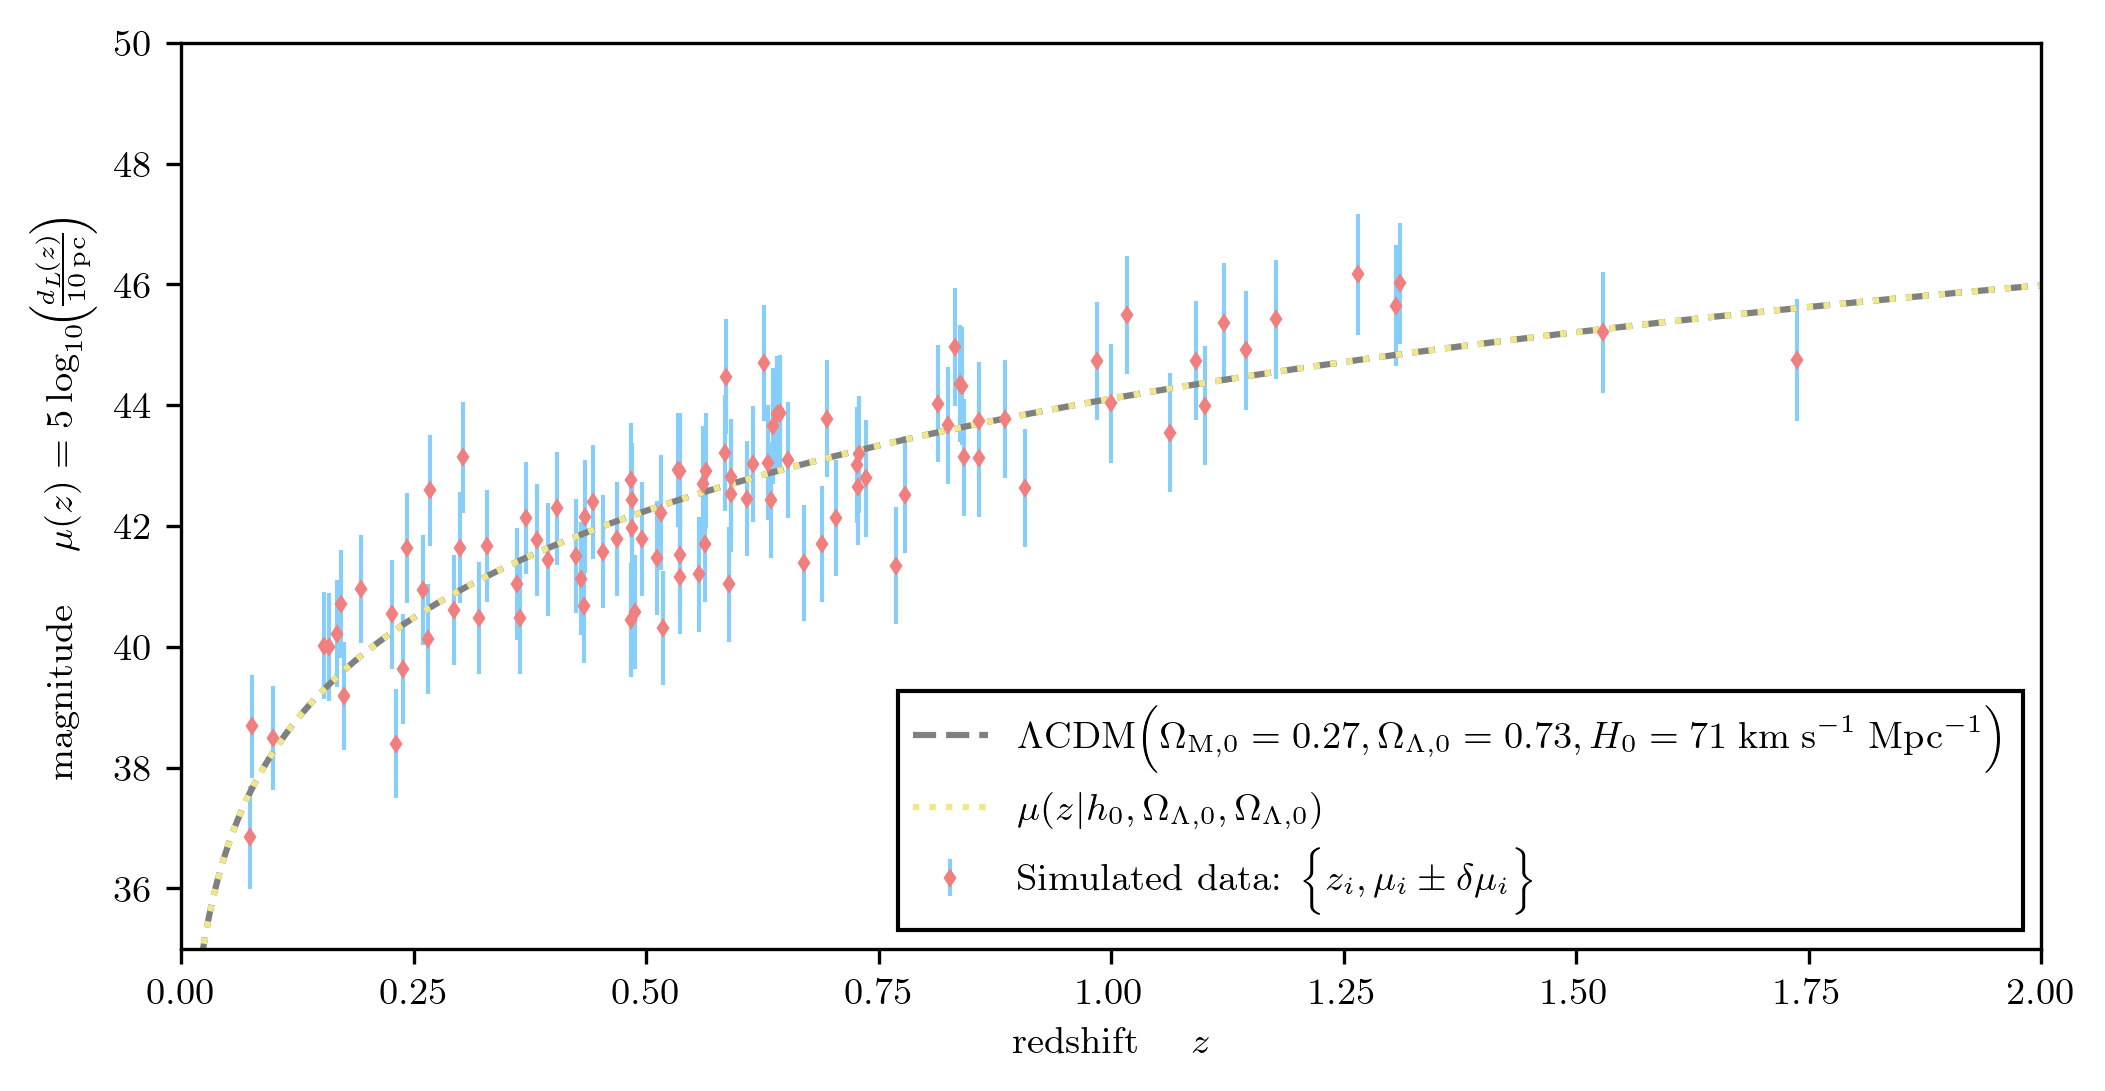

In [9]:
#-------------------------------------------------------------------------
# Generate data and visualize it
#-------------------------------------------------------------------------

z_sample, mu_sample, dmu = generate_mu_z(100, random_state=1234)

fig , ax = plt.subplots(figsize=(8,4))

plt.errorbar(z_sample, mu_sample, dmu, color='lightcoral', marker='d', markersize=2, ecolor='lightskyblue', ls='', lw=1, label=r'Simulated data: $\big\{z_i , \mu_i \pm \delta \mu_i\big\}$')
plt.xlabel(r"redshift $\quad z$")
plt.ylabel(r"magnitude $\quad \mu(z) = 5 \log_{10}\!\!\left(\!\frac{d_L\!(z)}{10\, \rm pc}\!\right)$")
plt.xlim(0,2)
plt.ylim(35,50)

#-------------------------------------------------------------------------
# I'm not supposed to know this but I'm not using this info, 
# just plotting it for comparison
#-------------------------------------------------------------------------

cosmo = LambdaCDM(H0=71, Om0=0.27, Ode0=1-0.27)

z_grid = np.linspace(0,2,1000)
mu_true = cosmo.distmod(z_grid)
label_LCDM = r'$\Lambda$CDM$\big(\Omega_{\rm M,0}=0.27 , \Omega_{\Lambda,0} = 0.73, H_0 = 71 \;\textup{km} \; \textup{s}^{-1} \; \textup{Mpc}^{-1}\big)$'
plt.plot(z_grid, mu_true, ls='--', color='gray', label=label_LCDM)

plt.plot( z_grid, mu_modellino([0.7104915227720638, 0.73], z=z_grid), ls=':', color='khaki', label='$\mu(z|h_0, \Omega_{\Lambda,0}, \Omega_{\Lambda,0})$' )

#-------------------------------------------------------------------------

ax.legend(loc=4, frameon=True, framealpha=1, fancybox=False, edgecolor='black' )


#-------------------------------------------------------------------------

# Flat $\Lambda\textup{CDM}$ cosmological model: nested sampling estimates for $\Omega_{\Lambda,0} $, $H_0$

The FRW metric is:

$$ \boxed{
g_{\mu\nu} = 
- c^2 \textup{d}t^2
+ a^2(t) \left( 
    \frac{1}{1 - kr^2} \; \textup{d}r^2 
    + r^2 \; \textup{d}\vartheta^2 
    + r^2 \sin^2\!\vartheta \; \textup{d} \varphi^2 
\right)
} $$

Computing the Christoffel symbols, it's easy to find that:

$$
\Gamma^0_{ij} = \frac{1}{c} \frac{\dot{a}(t)}{a(t)} g_{ij}
\quad ; \quad 
\Gamma^0_{00} = 0 
$$

So that the 0-component of the geodesic equation is:

$$
\frac{\textup{d}^2 x^0}{\textup{d}\tau^2} 
= - \Gamma^0_{\mu\nu} \frac{\textup{d} x^\mu}{\textup{d}\tau} \frac{\textup{d} x^\nu}{\textup{d}\tau} 
= 0 - \frac{1}{c} \frac{\dot{a}(t)}{a(t)} g_{ij} \frac{\textup{d} x^i}{\textup{d}\tau} \frac{\textup{d} x^j}{\textup{d}\tau}
= - \frac{\dot{a}(t)}{a(t)} \frac{| {\bm u}(t) |^2}{c} 
$$

But note also that:

$$
\frac{\textup{d}^2 x^0}{\textup{d}\tau^2} 
= \frac{\textup{d} u^0}{\textup{d} \tau} 
= \frac{\textup{d} t}{\textup{d} \tau} \frac{\textup{d} u^0}{\textup{d} t} 
= \gamma \frac{\textup{d} }{\textup{d} t} \sqrt{c^2 - |{\bm u}(t)|^2  }
= \gamma c \frac{\textup{d} }{\textup{d} t} \sqrt{ 1-\frac{|{\bm u}(t)|^2}{c^2} }
= \gamma c \frac{-2\dfrac{|{\bm u}(t)|}{c^2}}{2 \sqrt{ 1 - \dfrac{|{\bm u}(t)|^2}{c^2} }} \frac{\textup{d}|{\bm u}(t)|}{\textup{d} t} 
= -\gamma^2 \frac{|{\bm u}(t)|}{c} \frac{\textup{d}|{\bm u}(t)|}{\textup{d} t} 
$$

So that:

$$
-\gamma^2 \frac{|{\bm u}(t)|}{c} \frac{\textup{d}|{\bm u}(t)|}{\textup{d} t}  
= - \frac{\dot{a}(t)}{a(t)} \frac{| {\bm u}(t) |^2}{c} 
\quad \iff \quad
\frac{\textup{d}|{\bm u}(t)|}{\textup{d} t}
= \frac{\dot{a}(t)}{a(t)} \gamma^2 \, |{\bm u}(t)|
$$

Which leads to the reason why these are called comoving coordinates:

$$
{\rm if }\; |{\bm u}(t=0)|=0 \implies |{\bm u}(t)|=0 \;\,\forall\,t
$$

Imagine then two objects at $(t_0, r_1, \vartheta_0, \varphi_0 )$ and $(t_0, r_2, \vartheta_0, \varphi_0 )$. Then, their coordinate distance at $t_0$ is $r=r_2 - r_1$, and if their relative coordinate velocity is 0, their coordinate distance for all subsequent coordinate times $t$ will be the constant $r$. 

Instead, using the FRW metric, their physical proper distance is:

$$
\textup{d} s^2 
= \frac{a^2(t)}{1 - k r^2 } \; \textup{d} r^2 
\quad \implies \quad 
s(t) 
= a(t) \int_0^r \frac{\textup{d} r}{\sqrt{ 1  - kr^2 }}
= a(t) \, r 
\quad (\textup{if flat universe } k = 0)
$$

Consider now signals moving along the massless geodesic equation:

$$

\textup{d}s^2 = 0
\quad \iff \quad
c^2 \textup{d} t^2 
= \frac{a^2(t)}{1 - k r^2 } \; \textup{d} r^2 
\quad \iff \quad 
\int_{t_\textup{emiss}}^{t_\textup{obs}} 
\frac{c \,\textup{d}t}{a(t)}
= \int_0^r \frac{\textup{d} r}{\sqrt{ 1  - kr^2 }}
= \int_{t_\textup{emiss}+\delta t_\textup{emiss}}^{t_\textup{obs}+\delta t_\textup{obs}} 
\frac{c \,\textup{d}t}{a(t)}
$$

Then to first order:

$$
0 = \int_{t_\textup{emiss}+\delta t_\textup{emiss}}^{t_\textup{obs}+\delta t_\textup{obs}} 
\frac{c \,\textup{d}t}{a(t)}
- \int_{t_\textup{emiss}}^{t_\textup{obs}} 
\frac{c \,\textup{d}t}{a(t)}
\approx 
\frac{c \,\delta t_\textup{obs}}{a(t_\textup{obs})} 
- \frac{c \,\delta t_\textup{emiss}}{a(t_\textup{emiss})} 
\quad \iff \quad 
\delta t_\textup{obs} 
= \frac{a(t_\textup{obs})}{a(t_\textup{emiss})}
\delta t_\textup{emiss}
$$

Renaming $t_\textup{emiss} := t_s$ and $t_\textup{obs} = t_o$ then we define the redshift of a source:

$$ \boxed{
1 + z_s 
= \frac{a(t_o)}{a(t_s)} 
= \frac{ \textup{d} t_o }{ \textup{d} t_s } 
= \frac{ \nu_s }{ \nu_o } 
= \frac{ \textup{d} E_s }{ \textup{d} E_o } 
} $$

Then, the observed power of a source can be expressed in terms of its luminosity and the redshift as:

$$ \boxed{ 
\frac{ \textup{d} E_o }{ \textup{d} t_o }
= \frac{ \textup{d} E_s }{ \textup{d} t_s } 
\frac{ 1 }{ (1 + z_s)^2 }
= \frac{ L_s }{ (1 + z_s)^2 }
} $$

A detector measures the flux: power that spreads isotropically over a sphere of area: $\quad A_o = 4\pi a^2(t_o) r^2 $

$$ \boxed{
F_o 
= \frac{1}{A_o} \frac{ \textup{d} E_o }{ \textup{d} t_o } 
= \frac{ L_s }{ 4\pi \, a^2(t_o) \, r^2 \; (1 + z_s)^2 } 
=:  \frac{ L_s }{ 4\pi \, d_L^2(z_s) } 
} $$

Where we have finally defined the luminosity distance:

$$
d_L (z_s) = (1 + z_s) \, a(t_o) \, r
$$

We usually don't know $r$ though! So, Taylor expand as follows:

$$
\frac{1}{1+z_s} 
= \frac{a(t_s)}{a(t_o)}
= 1 
+ \frac{\dot{a}(t_o)}{a(t_o)} (t_s - t_o)
+ \frac{1}{2} \frac{\ddot{a}(t_o)}{a(t_o)} (t_s - t_o)^2 
+ ...
= 1 + H_0 (t_s - t_o) - \frac{1}{2} \frac{q_0}{H_0^2} (t_s - t_o)^2 +...
$$

And invert this $z_s(t_s - t_o)$ to find perturbatively $t_s(z_s)$. Then, remember we can compute $r$ with:

$$
\int_0^r \frac{\textup{d} r}{\sqrt{ 1  - kr^2 }}
= \int_{t_\textup{s}}^{t_\textup{o}} 
\frac{c \,\textup{d}t}{a(t)}
\quad 
\textup{insert here the expansion in terms of } t_s-t_o \textup{ and thus of } z_s 
$$

The result is the relation:

$$ \boxed{
\frac{H_0}{c} \, d_L(z_s) 
= z_s 
+ \frac{1}{2} \left( 1 + \frac{\ddot{a}(t_o)}{a(t_o)} \frac{1}{H_0^2} \right) z_s^2 
}
$$

Which to first order in $z_s$ is just the Hubble law. 

Note that we can differentiate the redshift definition:

$$
\frac{\textup{d}z}{\textup{d} t }
= \frac{\textup{d}}{\textup{d} t } \big( 1 + z(t) \big) 
= \frac{\textup{d}}{\textup{d} t } \frac{a(t_o)}{a(t)}
= - a(t_o) \frac{\dot{a}(t)}{a^2(t)}
= - \frac{a(t_o)}{a(t)} \, H\big(t(z)\big)
\quad \implies \quad
\frac{\textup{d} t}{a(t)}
= - \frac{1}{a(t_o) } \frac{\textup{d}z}{H(z)} 
$$

For a flat universe $k=0$ we can write:

$$
r = \int_0^r \frac{\textup{d} r}{\sqrt{ 1  - kr^2 }} \bigg|_{k=0}
= \int_{t_\textup{s}}^{t_\textup{o}} 
\frac{c \,\textup{d}t}{a(t)}
= - \frac{c}{a(t_o)} \int_{z_s}^0 \frac{\textup{d}z}{H(z)}
= \frac{c}{a(t_o)} \int_0^{z_s} \frac{\textup{d}z}{H(z)}
$$

So that finally we can write:

$$ \boxed{
d_L(z_s) 
= (1 + z_s) \, a(t_o) \, r
= (1 + z_s) \, c \int_0^{z_s} \frac{\textup{d}z}{H(z)}
} $$

Or equivalently taking the derivative with respect to the redshift:

$$ \boxed{
\frac{ \textup{d} }{ \textup{d} z} \left( \frac{d_L(z)}{1+z} \right)
= \frac{c}{H(z)}
} $$

Astronomers define the magnitude of a source as:

$$
\mu(z_s) = 5 \log_{10} \left( \dfrac{d_L(z_s)}{10 \textup{ pc}} \right)
$$

We then need an explicit expression for $H(z)$ which is computed depending on the cosmological model. 

Typically, for a flat ($k=0$) Universe with non-zero cosmological constant $\Lambda$:

$$ \boxed{
H(z) = \dfrac{\dot{a}\big(t(z)\big)}{a\big(t(z)\big)} 
= H_0 \sqrt{ \Omega_{\Lambda,0} + \Omega_{\textup{M},0} \, (1+z)^3}
\quad ; \quad 
\Omega_{\Lambda,0} + \Omega_{\textup{M},0} = 1
} $$

Then, the magnitude is:

$$
\mu(z_s) 
= 5 \log_{10} \left( \dfrac{d_L(z_s)}{10 \textup{ pc}} \right)
= 5 \log_{10} \left( 
    \dfrac{c}{10 \textup{ pc}} \, (1 + z_s) \, \int_0^{z_s} \dfrac{\textup{d}z}{H(z)} 
\right) 
= 5 \log_{10} \left( 
    \dfrac{c}{H_0 \, 10 \textup{ pc}} \, (1 + z_s) \, 
    \int_0^{z_s} \dfrac{\textup{d}z}{ \sqrt{ \Omega_{\Lambda,0} + \Omega_{\textup{M},0} \, (1+z)^3} } 
\right) 
$$

It is useful to re-write the constants as:

$$
\dfrac{c}{H_0} = \frac{3000 \textup{ Mpc}}{h_0} 
\implies
5 \log_{10} \left( \dfrac{c}{H_0 \, 10\textup{ pc}} \right)
= 5 \log_{10} \left( \frac{3 \cdot 10^9 \textup{ pc}}{10 \textup{ pc} } \right) - 5 \log_{10}\big(h_0 \big)
= 5 \log_{10} \big( 3 \cdot 10^8 \big) - 5 \log_{10}\big(h_0 \big)
= 5K - 5 \log_{10}\big(h_0 \big)
$$

And to note that the integral is an hypergeometric function:

$$
\int_0^{z} \dfrac{\textup{d}z'}{ \sqrt{ \Omega_{\Lambda,0} + \Omega_{\textup{M},0} \, (1+z')^3} } 
= \Bigg[ 
\frac{1}{\sqrt{\Omega_{\Lambda,0}}} 
\, (1 + z)
\phantom{0}_{2}F_{1} \left( \frac{1}{3};\frac{1}{2};\frac{4}{3};-\frac{\Omega_{\textup{M},0}}{\Omega_{\Lambda,0}} (1+z)^3 \right)
\Bigg]^z_0
% \, \sqrt{ \Omega_{\Lambda,0} + \Omega_{\textup{M},0} \, (1+z)^3} 
% \; \phantom{0}_{2}F_{1} \left( \frac{5}{6} ; 1 ; \frac{4}{3} ; - \frac{\Omega_{\textup{M},0}}{\Omega_{\Lambda,0}} (1+z)^3 \right)
$$

Our parametric model for the magnitude is then:

$$ \boxed{
\begin{array}{rcl}
    \frac{1}{5} \, \mu \big(z | h_0 , \Omega_{\Lambda,0} , \Omega_{\textup{M},0} = 1 - \Omega_{\Lambda,0} \big) 
    \!\!&\!\!=\!\!&\!\!
    \log_{10} ( 1 + z ) - \log_{10} h_0 - \frac{1}{2}\log_{10} \Omega_{\Lambda,0} + \log_{10} \!\big( 3 \cdot 10^8 \big)
% \\ \\
%     \phantom{ \frac{1}{5} \, \mu \big(z | h_0 , \Omega_{\Lambda,0} , \Omega_{\textup{M},0} \big) } 
%     \!\!&\!\! + \!\!&\!\!
%     \frac{1}{2} \log_{10} \Big( \Omega_{\Lambda,0} + \Omega_{\textup{M},0} \, (1+z)^3 \Big)
\\ \\
    \phantom{ \frac{1}{5} \, \mu \big(z | h_0 , \Omega_{\Lambda,0} , \Omega_{\textup{M},0} = 1 - \Omega_{\Lambda,0} \big) } 
    \!\!&\!\! + \!\!&\!\!
    \log_{10} \!\bigg( % \bigg[ 
        (1+z)
        \!\!\phantom{0}_{2}F_{1} \Big( \frac{1}{3};\frac{1}{2};\frac{4}{3}; - \frac{\Omega_{\textup{M},0}}{\Omega_{\Lambda,0}} (1+z)^3 \Big) 
        - \!\!\phantom{0}_{2}F_{1} \Big( \frac{1}{3};\frac{1}{2};\frac{4}{3}; - \frac{\Omega_{\textup{M},0}}{\Omega_{\Lambda,0}}\Big) 
    \bigg) % \bigg]^z_0 \!
% \\ \\
% \phantom{ \frac{1}{5} \, \mu \big(z | h_0 , \Omega_{\Lambda,0} , \Omega_{\textup{M},0} \big) } 
% \!\!&\!\! - \!\!&\!\!
%     \log_{10} h_0 - \frac{1}{2}\log_{10} \Omega_{\Lambda,0} + K
\end{array} }
$$





$$
\mathcal{L} \big( \{ \mu_i, \sigma_i , z_i \} \,|\, h_0 , \Omega_{\Lambda,0} , \Omega_{\textup{M},0} = 1\!-\!\Omega_{\Lambda,0}\big)
= \prod_{i=1}^{N_{\textup{samples}}} 
\frac{1}{\sigma_i \sqrt{2\pi}} \;
\exp\left({ \displaystyle
    - \frac{ 
        \big( \mu_i -  \mu (z_i \,|\, h_0 , \Omega_{\Lambda,0} , \Omega_{\textup{M},0} = 1 \!-\!\Omega_{\Lambda,0}) \big)^2 
    }{ 2\sigma_i^2}
} \right)
$$

% $ 
% \textup{Note:}
% \quad 
% \ln\!\big( e^{ \log_{10}(f)} \big) 
% = \log_{10}(f) \ln e 
% = \log_{10}(f)
% \quad \implies\quad
% \ln\!\big( e^{ - g/\sigma } \cdot e^{+ \log_{10}(f)/\sigma} \big) 
% = -g/\sigma +\log_{10}(f)/\sigma 
% $

$$
\ln\mathcal{L} \big( \{ \mu_i, \sigma_i , z_i \} \,|\, h_0 , \Omega_{\Lambda,0} , \Omega_{\textup{M},0} = 1\!-\!\Omega_{\Lambda,0} \big)
= \textup{const} 
- \!\!\!\sum_{i=1}^{N_{\textup{samples}}} \!
\ln\!\big( \sigma_i \big) \;
- \!\sum_{i=1}^{N_{\textup{samples}}} \!
{ \displaystyle
    \frac{ 
        \big( \mu_i -  \mu (z_i \,|\, h_0 , \Omega_{\Lambda,0} , \Omega_{\textup{M},0} = 1 \!-\!\Omega_{\Lambda,0}) \big)^2 
    }{ 2\sigma_i^2}
}
$$


In [ ]:
#-------------------------------------------------------------------------
# our model for mu(z | h0, OmegaLambda0, OmegaMatter0=1-OmegaLambda0)

const3e7 = np.log10(3e8)

def mu_modellino(params, z):
    h, OmegaL = params
    OmegaM = 1. - OmegaL
    var_z  = 1. + z
    result = np.log10(var_z) - np.log10(h) - 0.5 * np.log10(OmegaL) 
    hyper21 = var_z * special.hyp2f1(1/3,1/2,4/3,-OmegaM/OmegaL * var_z**3) - special.hyp2f1(1/3,1/2,4/3,-OmegaM/OmegaL)
    return 5*(result + np.log10(hyper21) + const3e7)

def log_likelihood(params, z, mu_z, dmu_z):
    return - np.sum( (mu_z - mu_modellino(params, z))**2 / (2 * dmu_z**2) + np.log(dmu_z))

def log_prior(params):    
    h, OmegaL = params
    if  (0.5 < h < 1.0) and (0. < OmegaL < 1.):
        return np.log(1/0.5)
    else:
        return -np.inf
    
def prior_transform(params):
    h, OmegaL = params 
    # h, OmegaL, OmegaM = params
    transform_h = stats.uniform(loc=0,scale=1).ppf(h)
    transform_OmegaL = stats.uniform(loc=0,scale=1).ppf(OmegaL)
    # transform_OmegaM = stats.uniform(loc=0,scale=1).ppf(OmegaM)
    return np.array([transform_h, transform_OmegaL]) #, transform_OmegaM])

def log_posterior(params, z, mu_z, dmu_z):
    return log_likelihood(params, z, mu_z, dmu_z) + log_prior(params)

#-------------------------------------------------------------------------

In [11]:
#-------------------------------------------------------------------------
# run Nested Sampling to sample the posterior (and the evidence!)

n_dim = 2
n_live_points = int(1e6) # 1000000

sampler = dynesty.NestedSampler(log_likelihood, prior_transform, n_dim, logl_args=(z_sample, mu_sample, dmu), nlive=n_live_points)
sampler.run_nested()
sresults = sampler.results

print('dynesty: done')

#-------------------------------------------------------------------------

100795it [05:13, 321.78it/s, +1000000 | bound: 0 | nc: 1 | ncall: 1106130 | eff(%): 99.518 | loglstar:   -inf < -40.919 <    inf | logz: -43.816 +/-    nan | dlogz:  0.000 > 1000.009]


dynesty: done


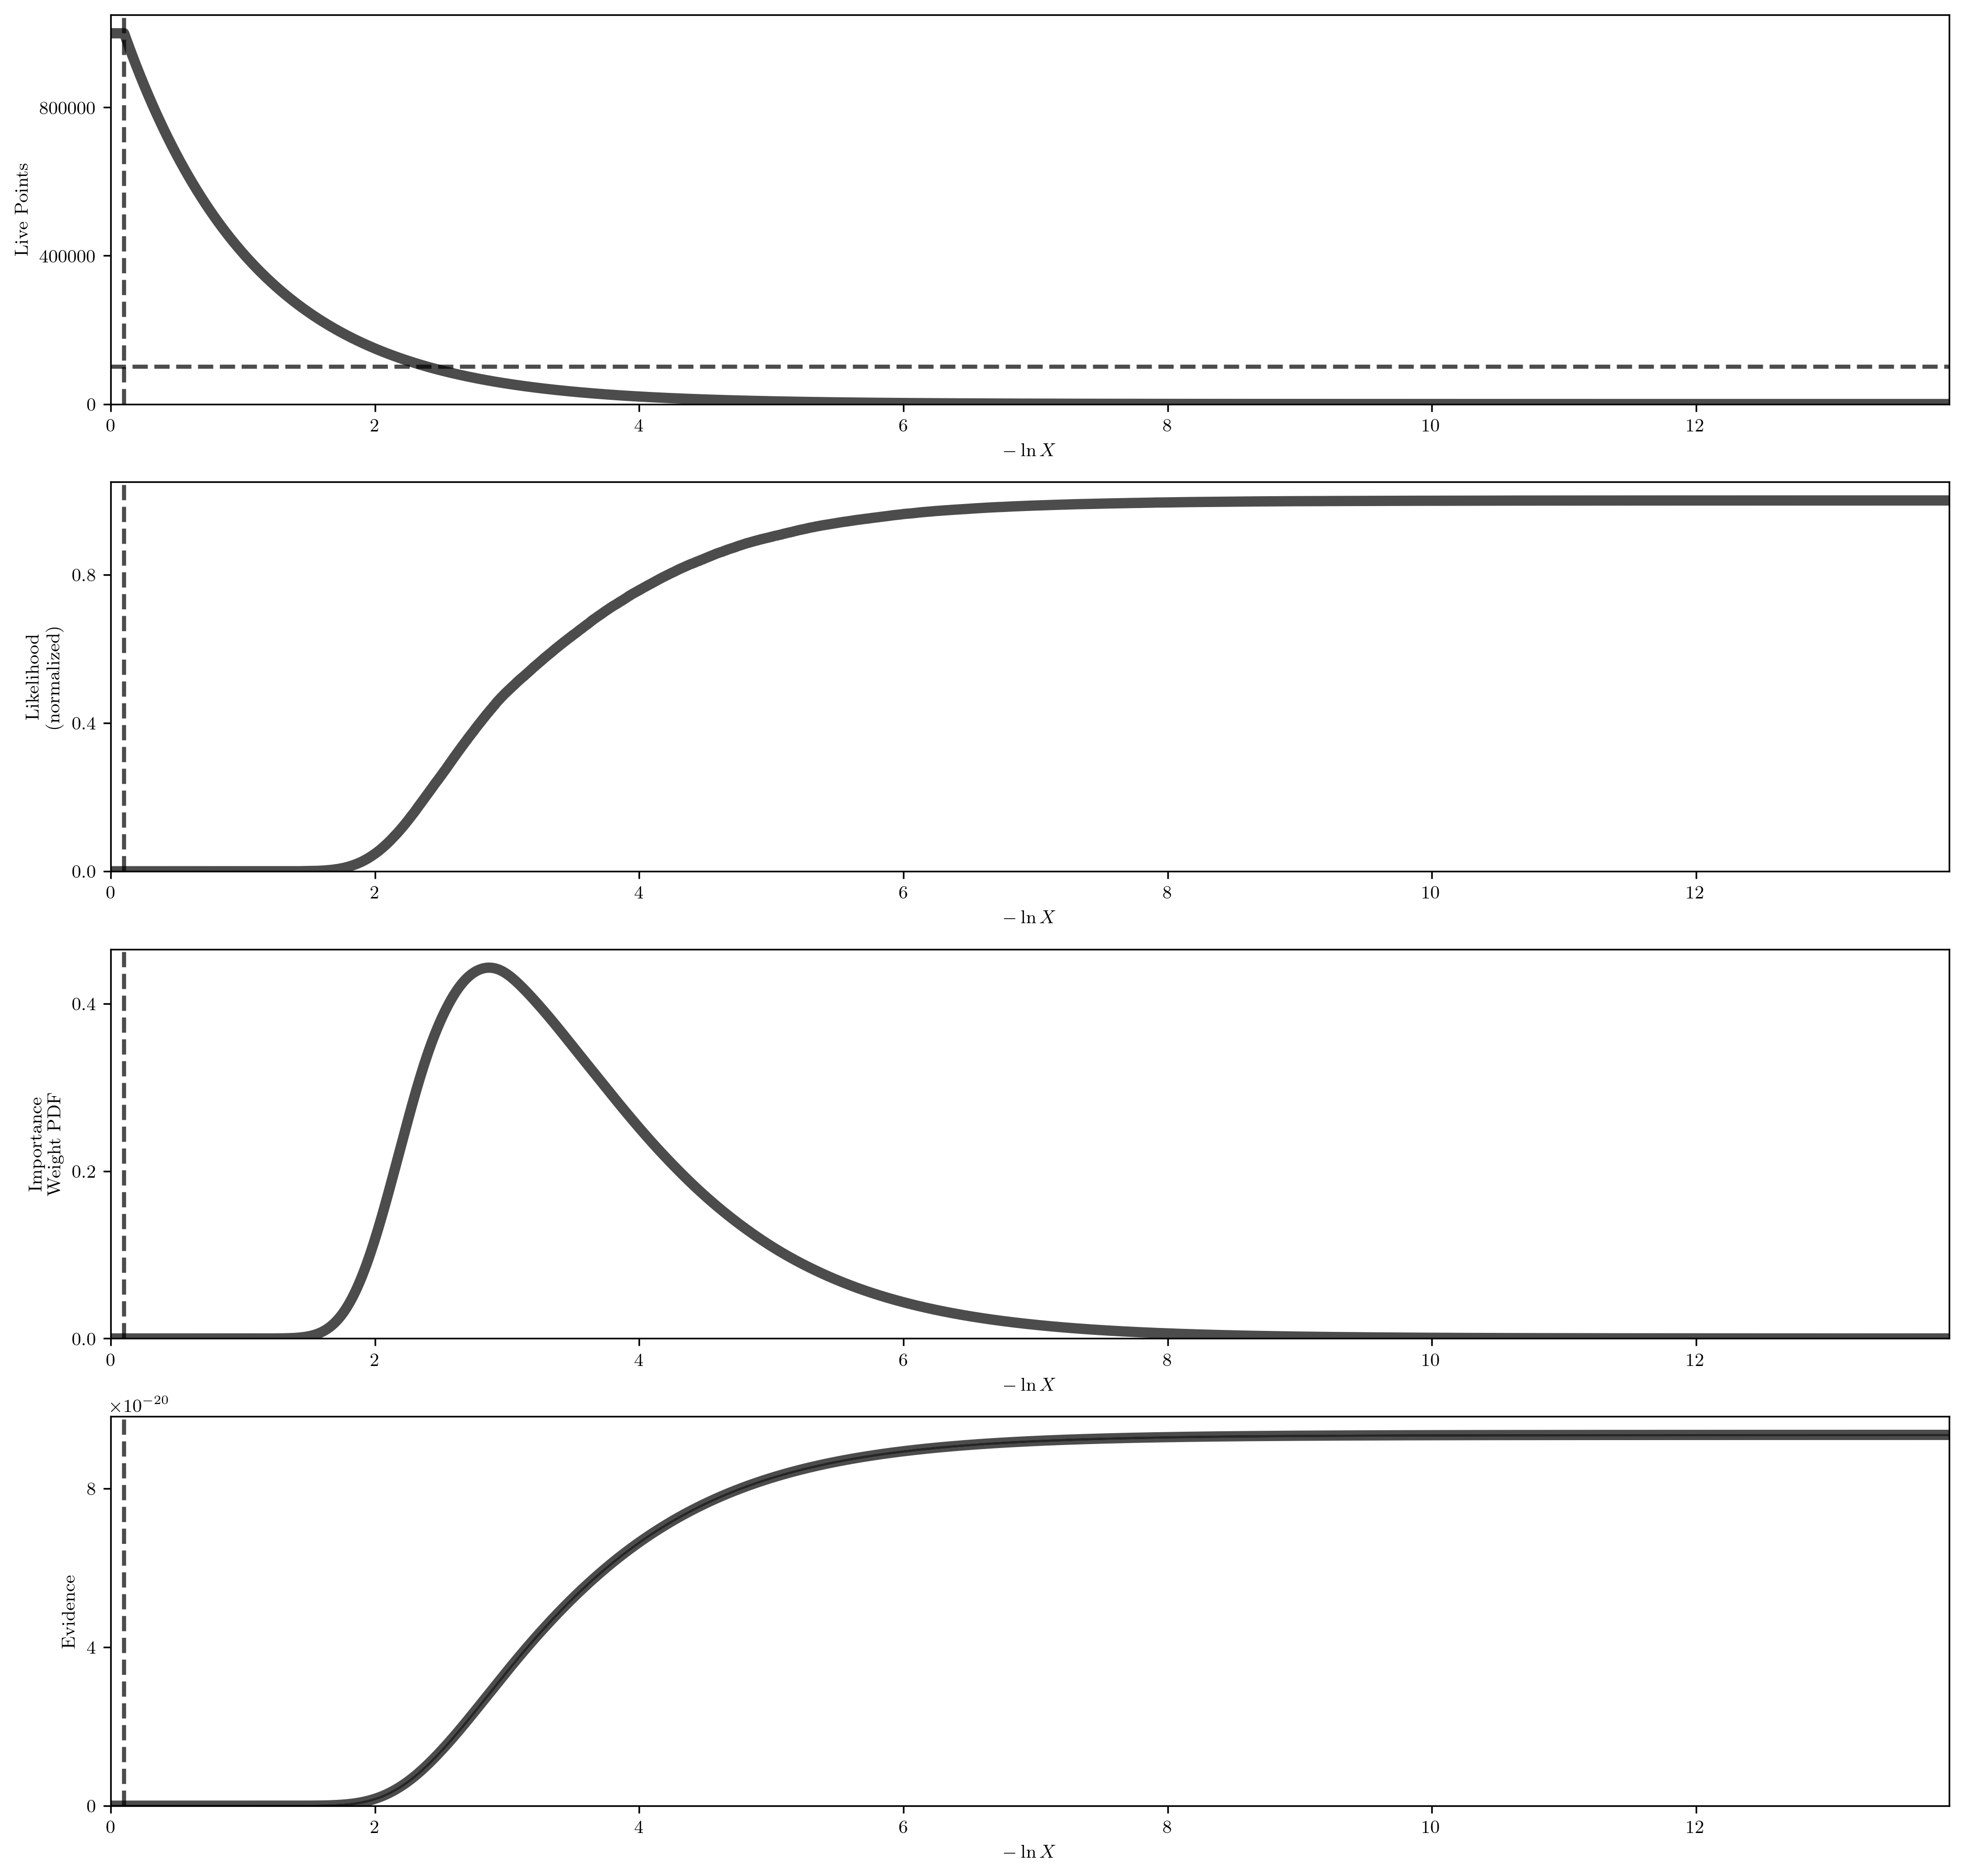

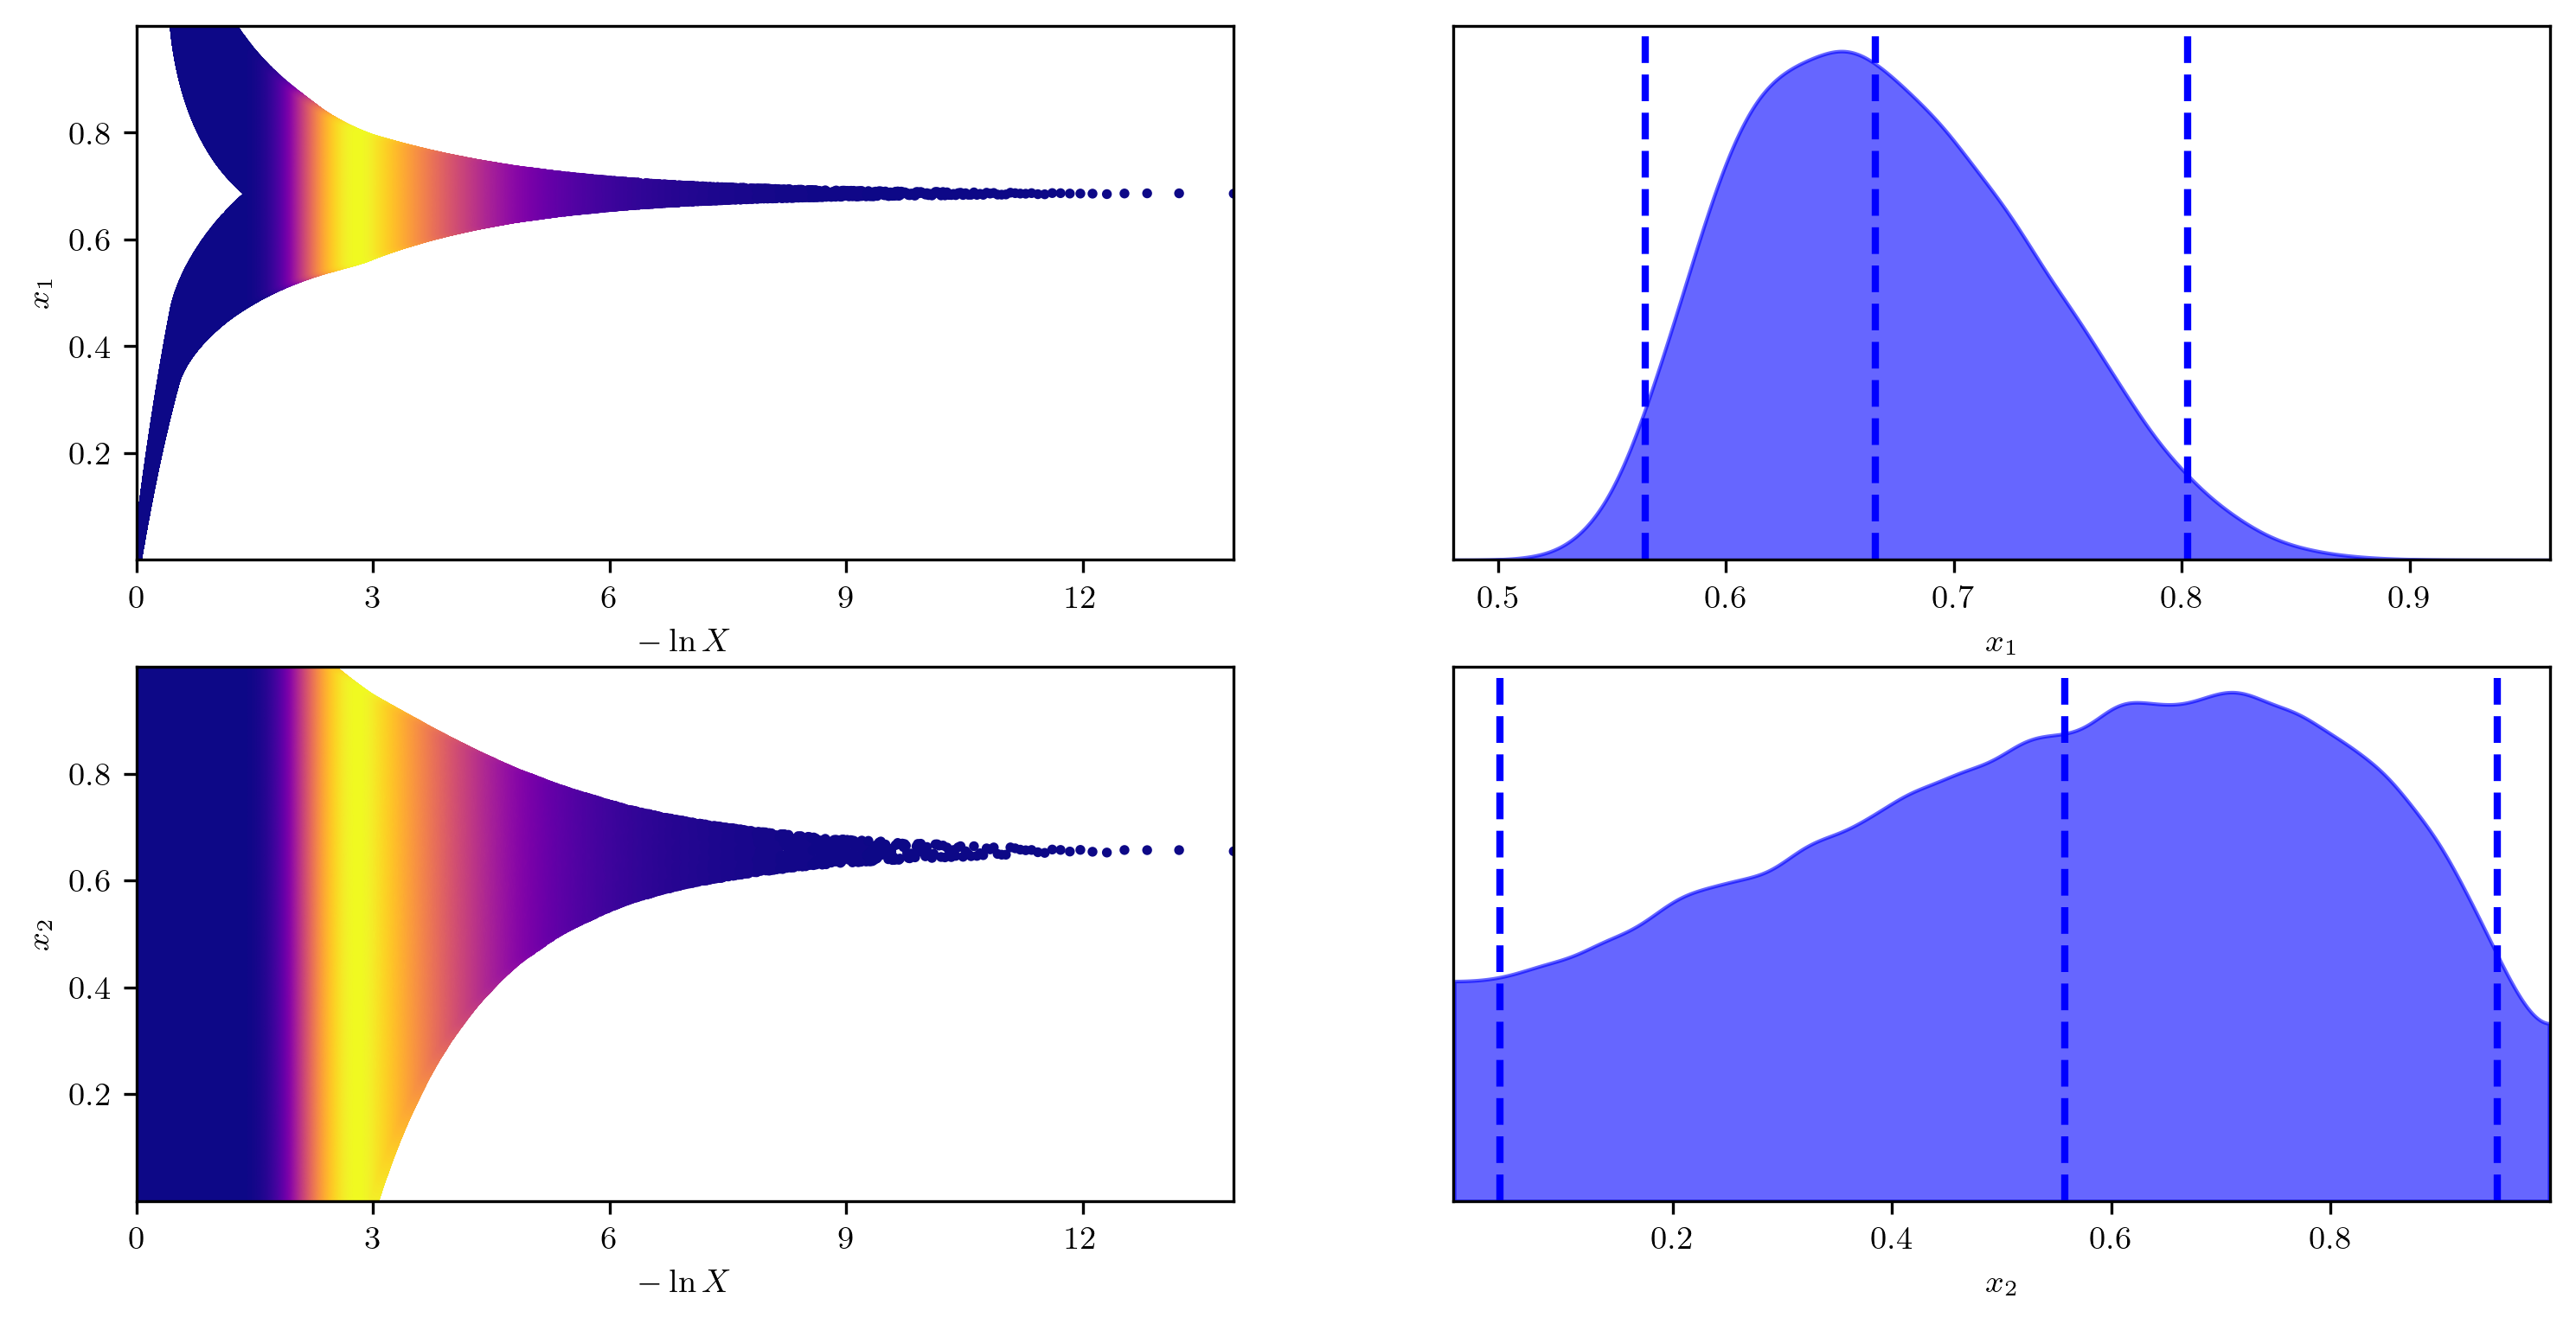

In [12]:
rfig, raxes = dyplot.runplot(sresults, color='black')

tfig, taxes = dyplot.traceplot(sresults)

(1100795,)


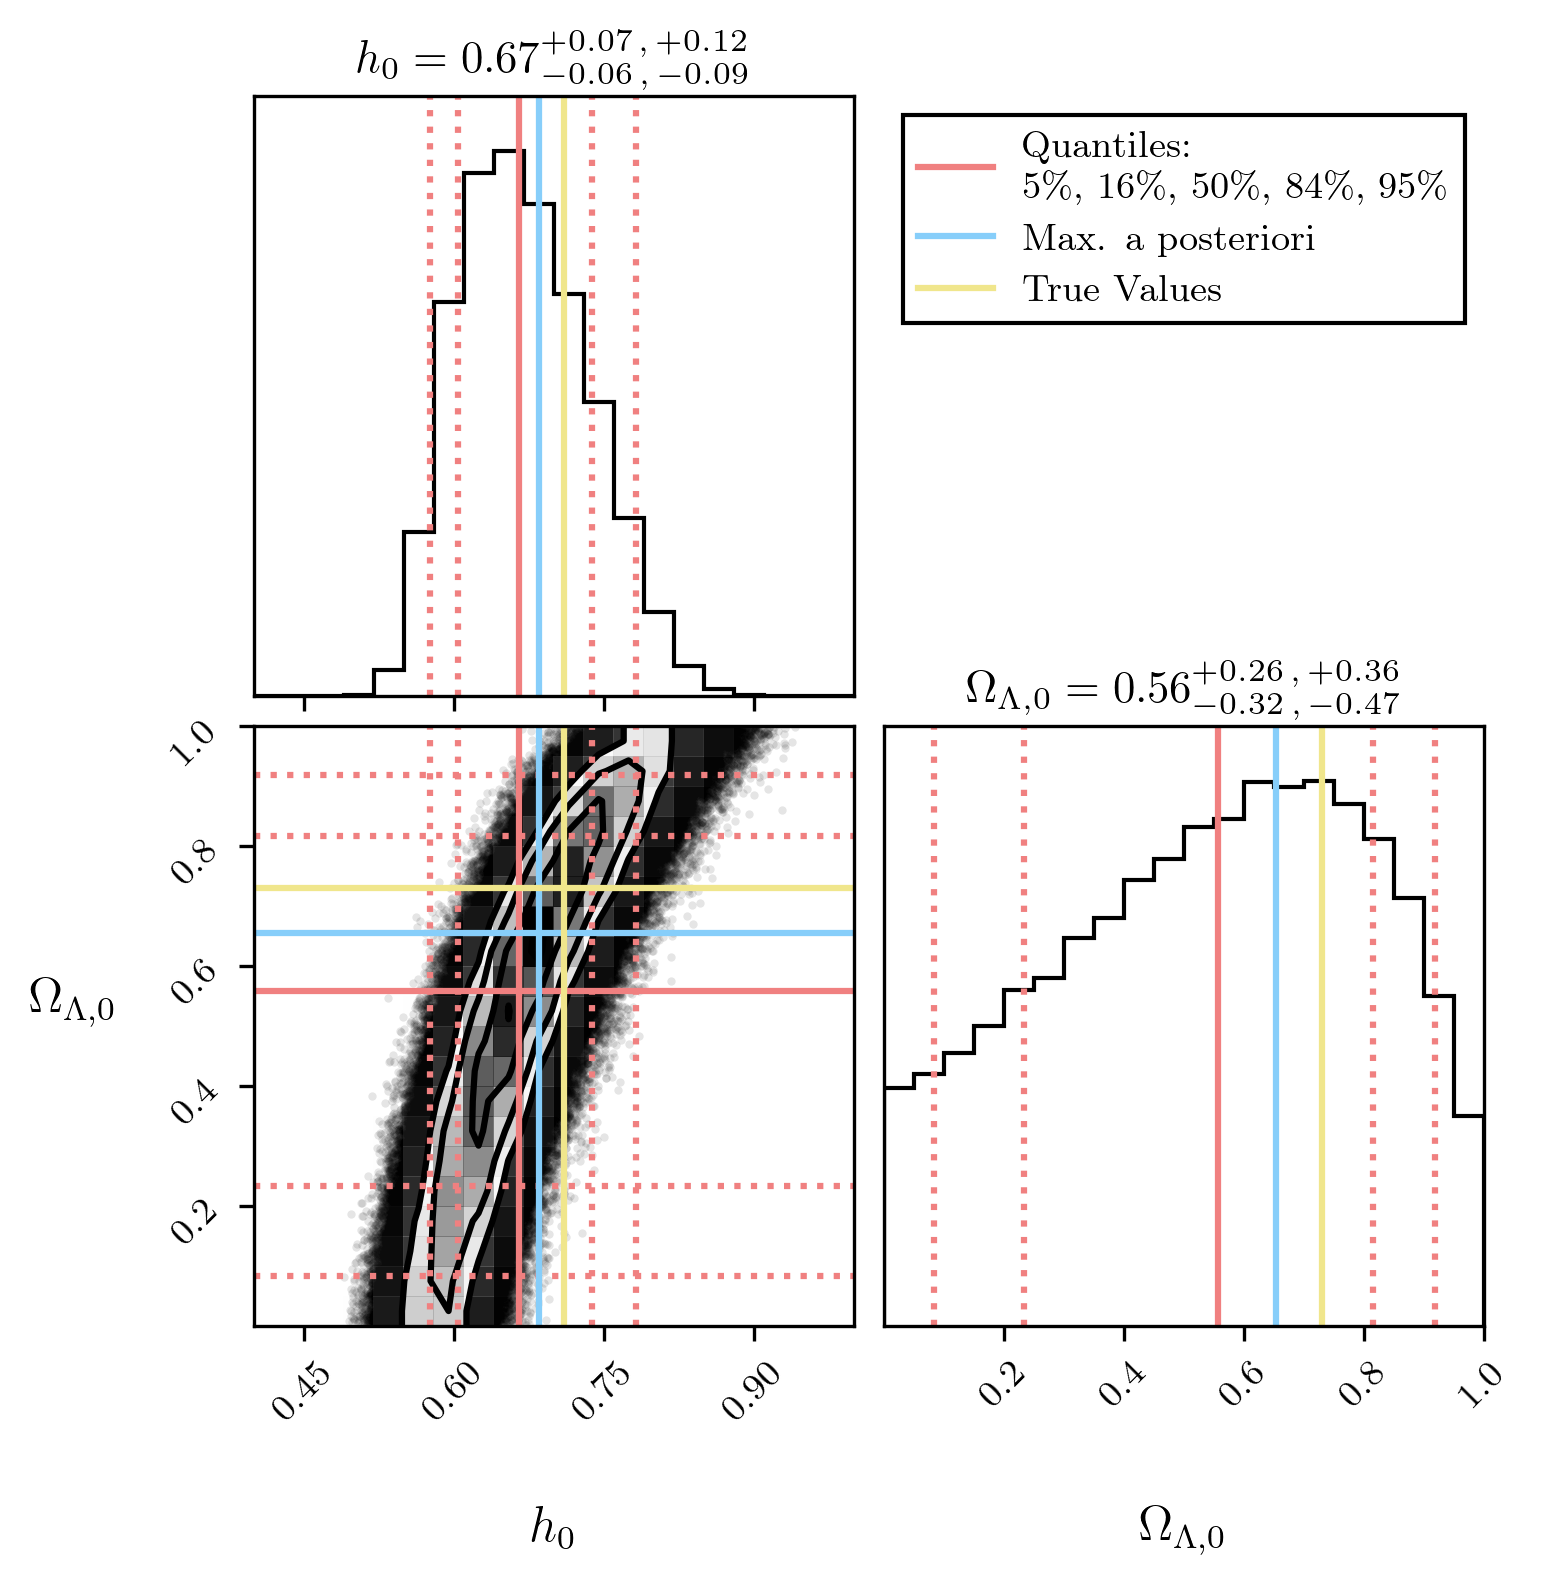

In [98]:
#-------------------------------------------------------------------------
# corner plot  of the nested sampling paramters 

samples = sresults.samples  
normalized_weights = np.exp(sresults.logwt - sresults.logz[-1])
samples_equal = dyfunc.resample_equal(samples, normalized_weights)

#-------------------------------------------------------------------------
# create the corner plot setup with the corner python package
# dynesty built-in corner plots: 
# cfig, caxes = dyplot.cornerplot(sresults1)

params_latex = [r'$h_0$', r'$\Omega_{\Lambda,0}$', r'$\Omega_{M,0}$']
fontsize = 12
fig = corner.corner(
    samples_equal,
    labels=params_latex,
    verbose      = False,
    show_titles  = False,
    title_kwargs = {'fontsize':fontsize},
    label_kwargs = {'fontsize':fontsize, 'rotation':'horizontal'},
    range        = [(0.4,1.0), (0.,1.0)] # , (0.,1.1)]
)
ax = np.array(fig.axes).reshape((n_dim, n_dim))

#-------------------------------------------------------------------------
# compute ranked statistics for the marginals (1D histograms): quantiles

quantiles1 = np.zeros((5,n_dim))
for i in range(n_dim):
    quantiles1[:,i] = corner.quantile(samples_equal[:,i], q=[0.05, 0.16, 0.5, 0.84, 0.95])

#-------------------------------------------------------------------------
# print these quantiles results onto the histograms and as sub-titles 

ax[0,n_dim-1].plot([], [], marker='', color='lightcoral', label='Quantiles:\n5\%, 16\%, 50\%, 84\%, 95\%')

corner.overplot_lines(fig, quantiles1[2,:], color="lightcoral")
corner.overplot_lines(fig, quantiles1[0,:], color="lightcoral", ls=':')
corner.overplot_lines(fig, quantiles1[1,:], color="lightcoral", ls=':')
corner.overplot_lines(fig, quantiles1[3,:], color="lightcoral", ls=':')
corner.overplot_lines(fig, quantiles1[4,:], color="lightcoral", ls=':')

par_name = [r'h_0', r'\Omega_{\Lambda,0}', r'\Omega_{M,0}']
for i in range(n_dim):
    titles = '$' + par_name[i] + '=' + \
             '{:.2f}'.format(quantiles1[2,i]) + r'^{+' + \
             '{:.2f}'.format(quantiles1[3,i] - quantiles1[2,i]) + r'\, , \,+' + \
             '{:.2f}'.format(quantiles1[4,i] - quantiles1[2,i]) + r'}_{-'      + \
             '{:.2f}'.format(quantiles1[2,i] - quantiles1[1,i]) + r'\, , \,-'  + \
             '{:.2f}'.format(quantiles1[2,i] - quantiles1[0,i]) + r'}$'
    ax[i,i].set_title( titles )

par_median = quantiles1[2,:]

#-------------------------------------------------------------------------

ax[0,n_dim-1].plot([], [], marker='', color='lightskyblue', label='Max. a posteriori')

M = len(samples_equal[:,0])
print(samples_equal[:,0].shape)

samples_logpost = np.zeros(M)
for i in range(M):
    samples_logpost[i] = log_posterior( samples_equal[i,:], z_sample, mu_sample, dmu )

par_MAP = samples_equal[np.argmax(samples_logpost),:] 

corner.overplot_lines(fig, par_MAP, color="lightskyblue")

#-------------------------------------------------------------------------

ax[0,n_dim-1].plot([], [], marker='', color='khaki', label='True Values')

corner.overplot_lines(fig, [0.7104915227720638, 0.73], color="khaki")

#-------------------------------------------------------------------------
# utility: make legend, save figure:

ax[0,n_dim-1].legend(title_fontsize=9, fontsize=9, frameon=True, framealpha=1, fancybox=False, edgecolor='black')

if False:
    fig.savefig('./L18_images/L18_dynesty__Corner_Plot.pdf', bbox_inches='tight')
    fig.savefig('./L18_images/L18_dynesty__Corner_Plot.png', bbox_inches='tight')


$h_0=0.71, \Omega_{\Lambda,0} = 0.73, \Omega_{M,0} = 0.27 \quad $ (True values)
$h_0=0.67, \Omega_{\Lambda,0} = 0.56, \Omega_{M,0} = 0.44 \quad $ (Median)
$h_0=0.69, \Omega_{\Lambda,0} = 0.65, \Omega_{M,0} = 0.35 \quad $ (Maxima a Posteriori)


C:\Users\andre\AppData\Local\Temp\ipykernel_8728\3942894783.py:12: RuntimeWarning: divide by zero encountered in log10
  return 5*(result + np.log10(hyper21) + const3e7)
C:\Users\andre\AppData\Local\Temp\ipykernel_8728\3942894783.py:12: RuntimeWarning: divide by zero encountered in log10
  return 5*(result + np.log10(hyper21) + const3e7)
C:\Users\andre\AppData\Local\Temp\ipykernel_8728\3942894783.py:12: RuntimeWarning: divide by zero encountered in log10
  return 5*(result + np.log10(hyper21) + const3e7)


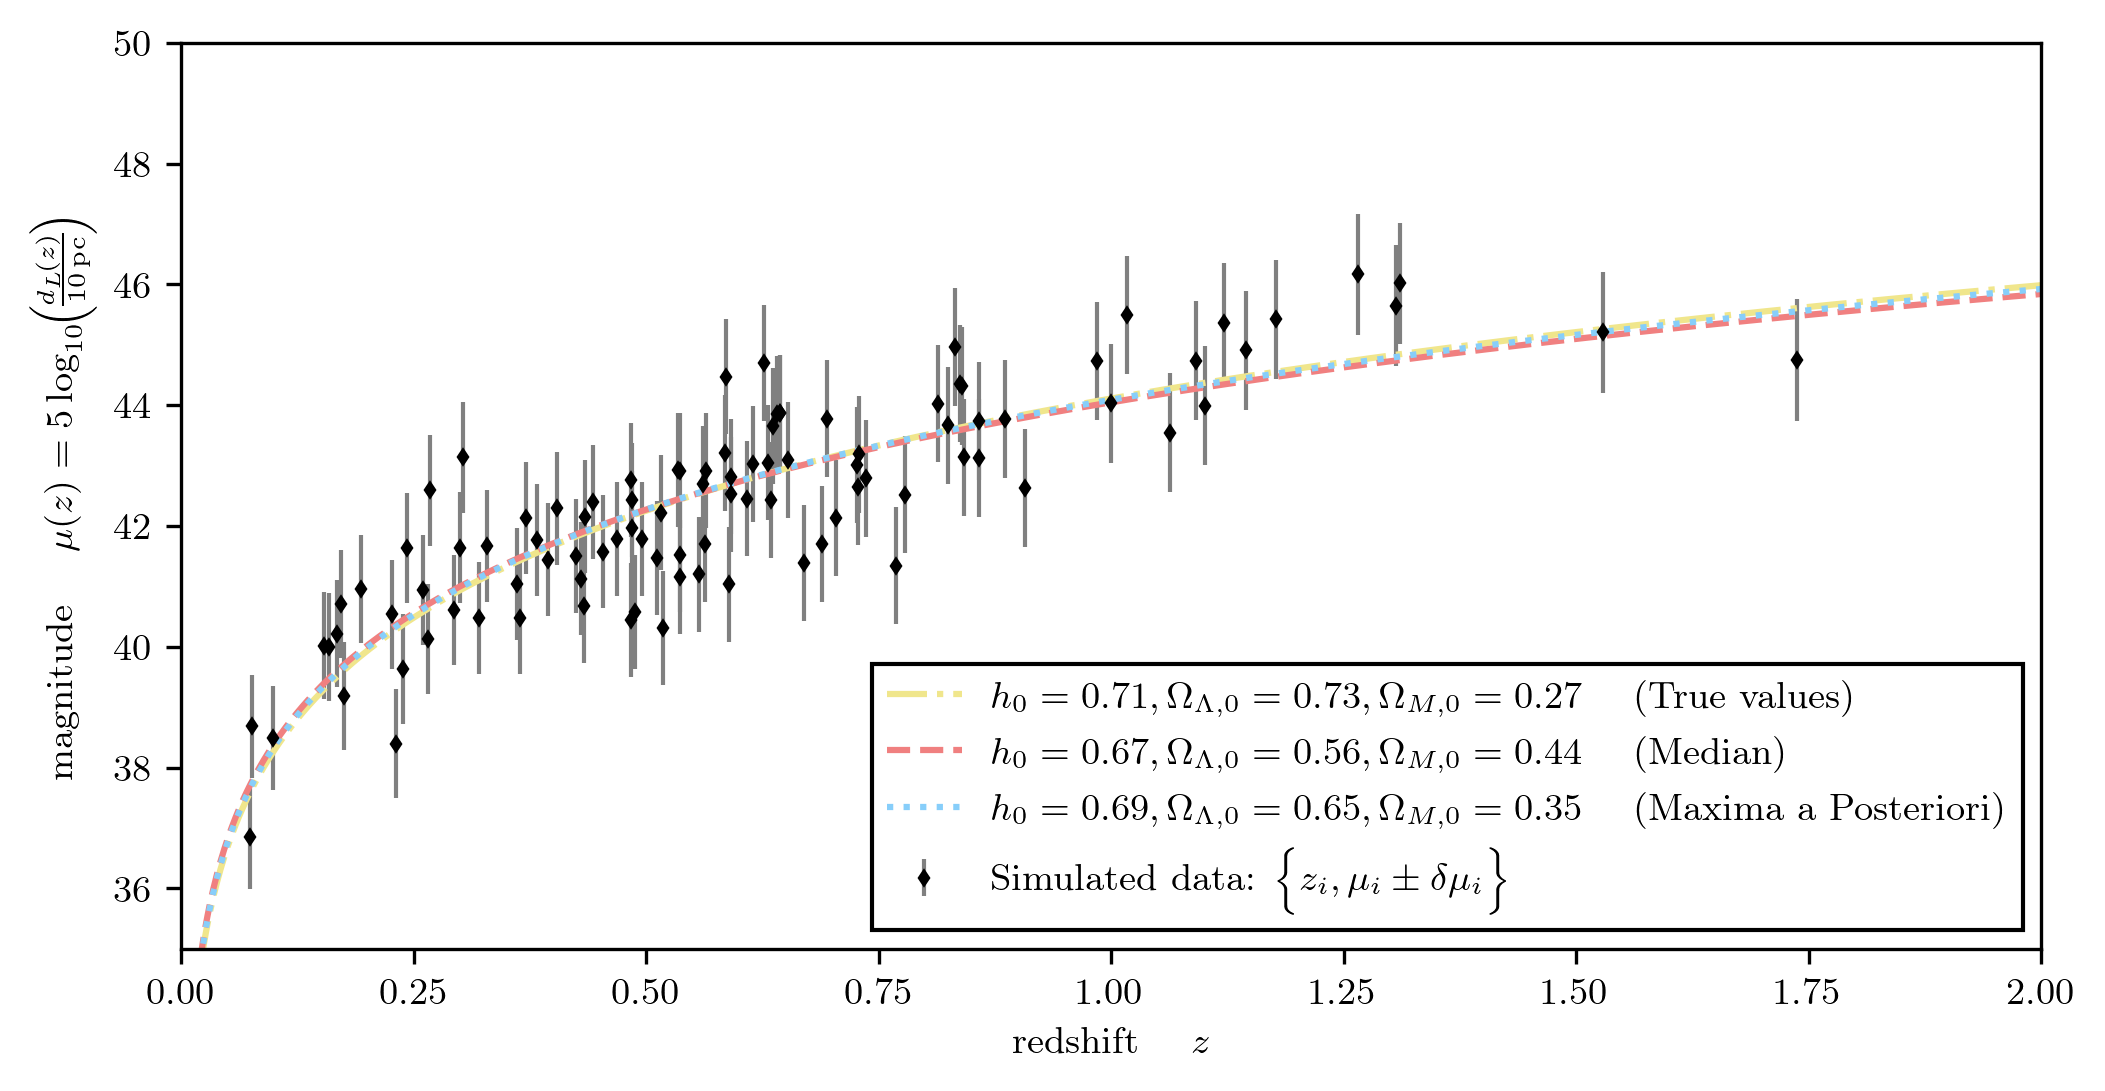

In [ ]:
#-------------------------------------------------------------------------
# Visualize the result of the nested sampling fit
#-------------------------------------------------------------------------

fig , ax = plt.subplots(figsize=(8,4))

plt.errorbar(z_sample, mu_sample, dmu, color='black', marker='d', markersize=2, ecolor='gray', ls='', lw=1, label=r'Simulated data: $\big\{z_i , \mu_i \pm \delta \mu_i\big\}$')
plt.xlabel(r"redshift $\quad z$")
plt.ylabel(r"magnitude $\quad \mu(z) = 5 \log_{10}\!\!\left(\!\frac{d_L\!(z)}{10\, \rm pc}\!\right)$")
plt.xlim(0,2)
plt.ylim(35,50)

label_Tru = '$h_0={:.2f}, '.format(0.71)
label_Tru += '\Omega_{\Lambda,0} = '
label_Tru += '{:.2f}, '.format(0.73)
label_Tru += '\Omega_{M,0} = '
label_Tru += '{:.2f} \quad $ (True values)'.format(0.27)
print(label_Tru)

plt.plot( z_grid, mu_modellino([0.71, 0.73], z=z_grid), ls='-.', color='khaki', label=label_Tru )

label_median = '$h_0={:.2f}, '.format(par_median[0])
label_median += '\Omega_{\Lambda,0} = '
label_median += '{:.2f}, '.format(par_median[1])
label_median += '\Omega_{M,0} = '
label_median += '{:.2f} \quad $ (Median)'.format(1-par_median[1])
print(label_median)

plt.plot( z_grid, mu_modellino(par_median, z=z_grid), ls='--', color='lightcoral', label=label_median)

label_MAP = '$h_0={:.2f}, '.format(par_MAP[0])
label_MAP += '\Omega_{\Lambda,0} = '
label_MAP += '{:.2f}, '.format(par_MAP[1])
label_MAP += '\Omega_{M,0} = '
label_MAP += '{:.2f} \quad $ (Maxima a Posteriori)'.format(1-par_MAP[1])
print(label_MAP)

plt.plot( z_grid, mu_modellino(par_MAP, z=z_grid), ls=':', color='lightskyblue', label=label_MAP)

#-------------------------------------------------------------------------

ax.legend(loc=4, frameon=True, framealpha=1, fancybox=False, edgecolor='black' )

if False:
    fig.savefig('./L18_images/L18_dynesty__Results.pdf', bbox_inches='tight')
    fig.savefig('./L18_images/L18_dynesty__Results.png', bbox_inches='tight')

#-------------------------------------------------------------------------

# Flat $\Lambda\textup{CDM}$ cosmological model: nested sampling estimates for only $H_0$


We need to modify our expression for $H(z)$ if we want to set $\Omega_{\Lambda,0} = 0$:

$$ \boxed{
H(z) = \dfrac{\dot{a}\big(t(z)\big)}{a\big(t(z)\big)} 
= H_0 \sqrt{ \Omega_{\textup{M},0} \, (1+z)^3}
\quad ; \quad 
\Omega_{\textup{M},0} = 1
} $$

Then, the magnitude is:

$$
\mu(z_s) 
= 5 \log_{10} \left( \dfrac{d_L(z_s)}{10 \textup{ pc}} \right)
= 5 \log_{10} \left( 
    \dfrac{c}{10 \textup{ pc}} \, (1 + z_s) \, \int_0^{z_s} \dfrac{\textup{d}z}{H(z)} 
\right) 
= 5 \log_{10} \left( 
    \dfrac{c}{H_0 \, 10 \textup{ pc}} \, (1 + z_s) \, 
    \int_0^{z_s} \dfrac{\textup{d}z}{ \sqrt{ (1+z)^3} } 
\right) 
$$

As done previously, we re-write the constants as:

$$
\dfrac{c}{H_0} = \frac{3000 \textup{ Mpc}}{h_0} 
\implies
5 \log_{10} \left( \dfrac{c}{H_0 \, 10\textup{ pc}} \right)
= 5 \log_{10} \left( \frac{3 \cdot 10^9 \textup{ pc}}{10 \textup{ pc} } \right) - 5 \log_{10}\big(h_0 \big)
= 5 \log_{10} \big( 3 \cdot 10^8 \big) - 5 \log_{10}\big(h_0 \big)
= 5K - 5 \log_{10}\big(h_0 \big)
$$

And note that the integral is:

$$
\int_0^{z} \dfrac{\textup{d}z'}{ \sqrt{ (1+z')^3} } 
= \Bigg[ 
\dfrac{- 2}{ \sqrt{ (1+z')} } 
\Bigg]^z_0
= \dfrac{- 2}{ \sqrt{ (1+z)} } 
+ 2 
$$

Our parametric model for the magnitude is then:

$$ \boxed{
\begin{array}{rcl}
    \frac{1}{5} \, \mu \big(z | h_0 , \Omega_{\Lambda,0} = 0 , \Omega_{\textup{M},0} = 1 \big) 
    \!\!&\!\!=\!\!&\!\!
    \log_{10} ( 1 + z ) - \log_{10} h_0 + \log_{10} \!\big( 3 \cdot 10^8 \big)
    + \log_{10} \!\Big( 
        2 - 2 (1+z)^{-\frac{1}{2}}
    \Big) 
\end{array} }
$$


In [87]:
#-------------------------------------------------------------------------
# our model without cosmological constant mu(z | h0, OmegaLambda0=0, OmegaMatter0=1)

def mu_no_Lambda(params, z):
    h = params
    var_z  = 1. + z
    result_1 = np.log10(var_z) - np.log10(h) 
    result_2 = np.log10(2. - 2. * var_z**(-1./2.))
    return 5*(result_1 + result_2 + const3e7)

def log_likelihood_no_Lambda(params, z, mu_z, dmu_z):
    return - np.sum( (mu_z - mu_no_Lambda(params, z))**2 / (2 * dmu_z**2) + np.log(dmu_z))

def log_prior_no_Lambda(params):    
    h = params
    if  (0.5 < h < 1.0):
        return np.log(1/0.5)
    else:
        return -np.inf

def prior_transform_no_Lambda(params):
    h = params 
    transform_h = stats.uniform(loc=0,scale=1).ppf(h)
    return transform_h

def log_posterior_no_Lambda(params, z, mu_z, dmu_z):
    return log_likelihood_no_Lambda(params, z, mu_z, dmu_z) + log_prior_no_Lambda(params)

#-------------------------------------------------------------------------

In [73]:
#-------------------------------------------------------------------------
# run Nested Sampling to sample the posterior (and the evidence!)

n_dim_no_Lambda = 1
n_live_points = int(1e6) # 1000000

sampler_no_Lambda = dynesty.NestedSampler(log_likelihood_no_Lambda, prior_transform_no_Lambda, n_dim_no_Lambda, logl_args=(z_sample, mu_sample, dmu), nlive=n_live_points)
sampler_no_Lambda.run_nested()
sresults_no_Lambda = sampler_no_Lambda.results

print('dynesty: done')

#-------------------------------------------------------------------------

86422it [03:39, 393.49it/s, +1000000 | bound: 0 | nc: 1 | ncall: 1090262 | eff(%): 99.648 | loglstar:   -inf < -41.637 <    inf | logz: -44.399 +/-    nan | dlogz:  0.000 > 1000.009]


dynesty: done


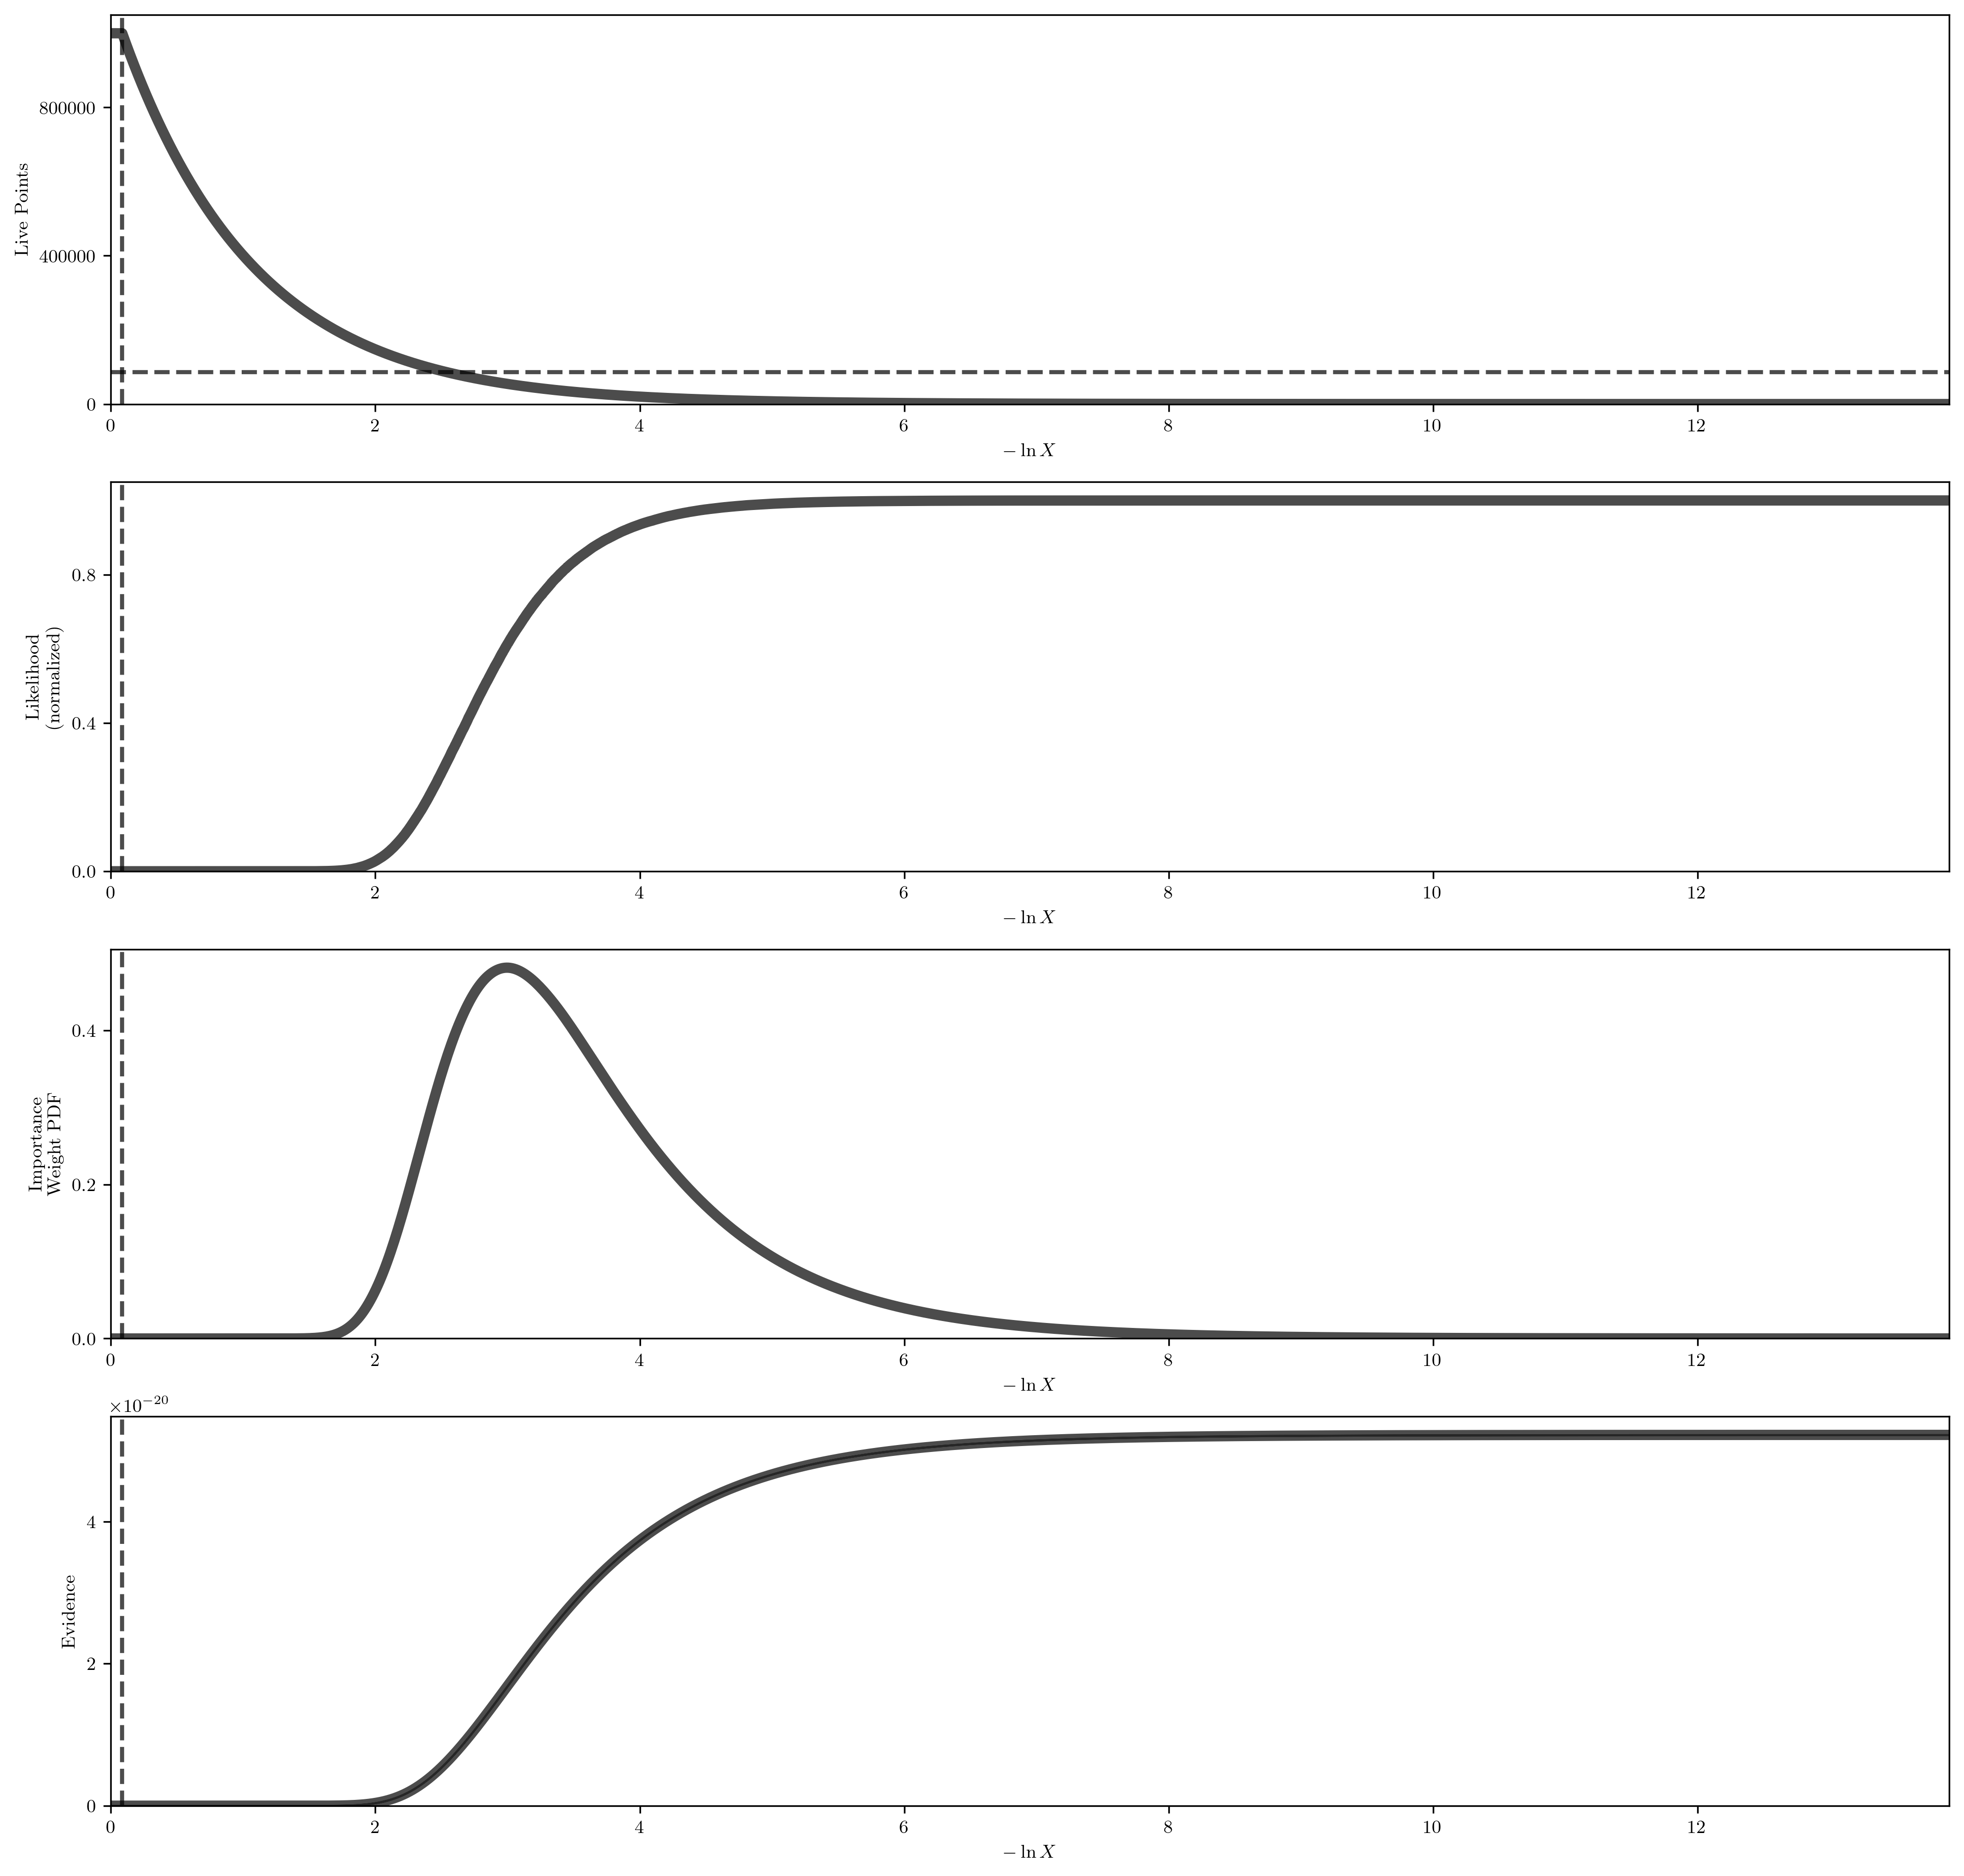

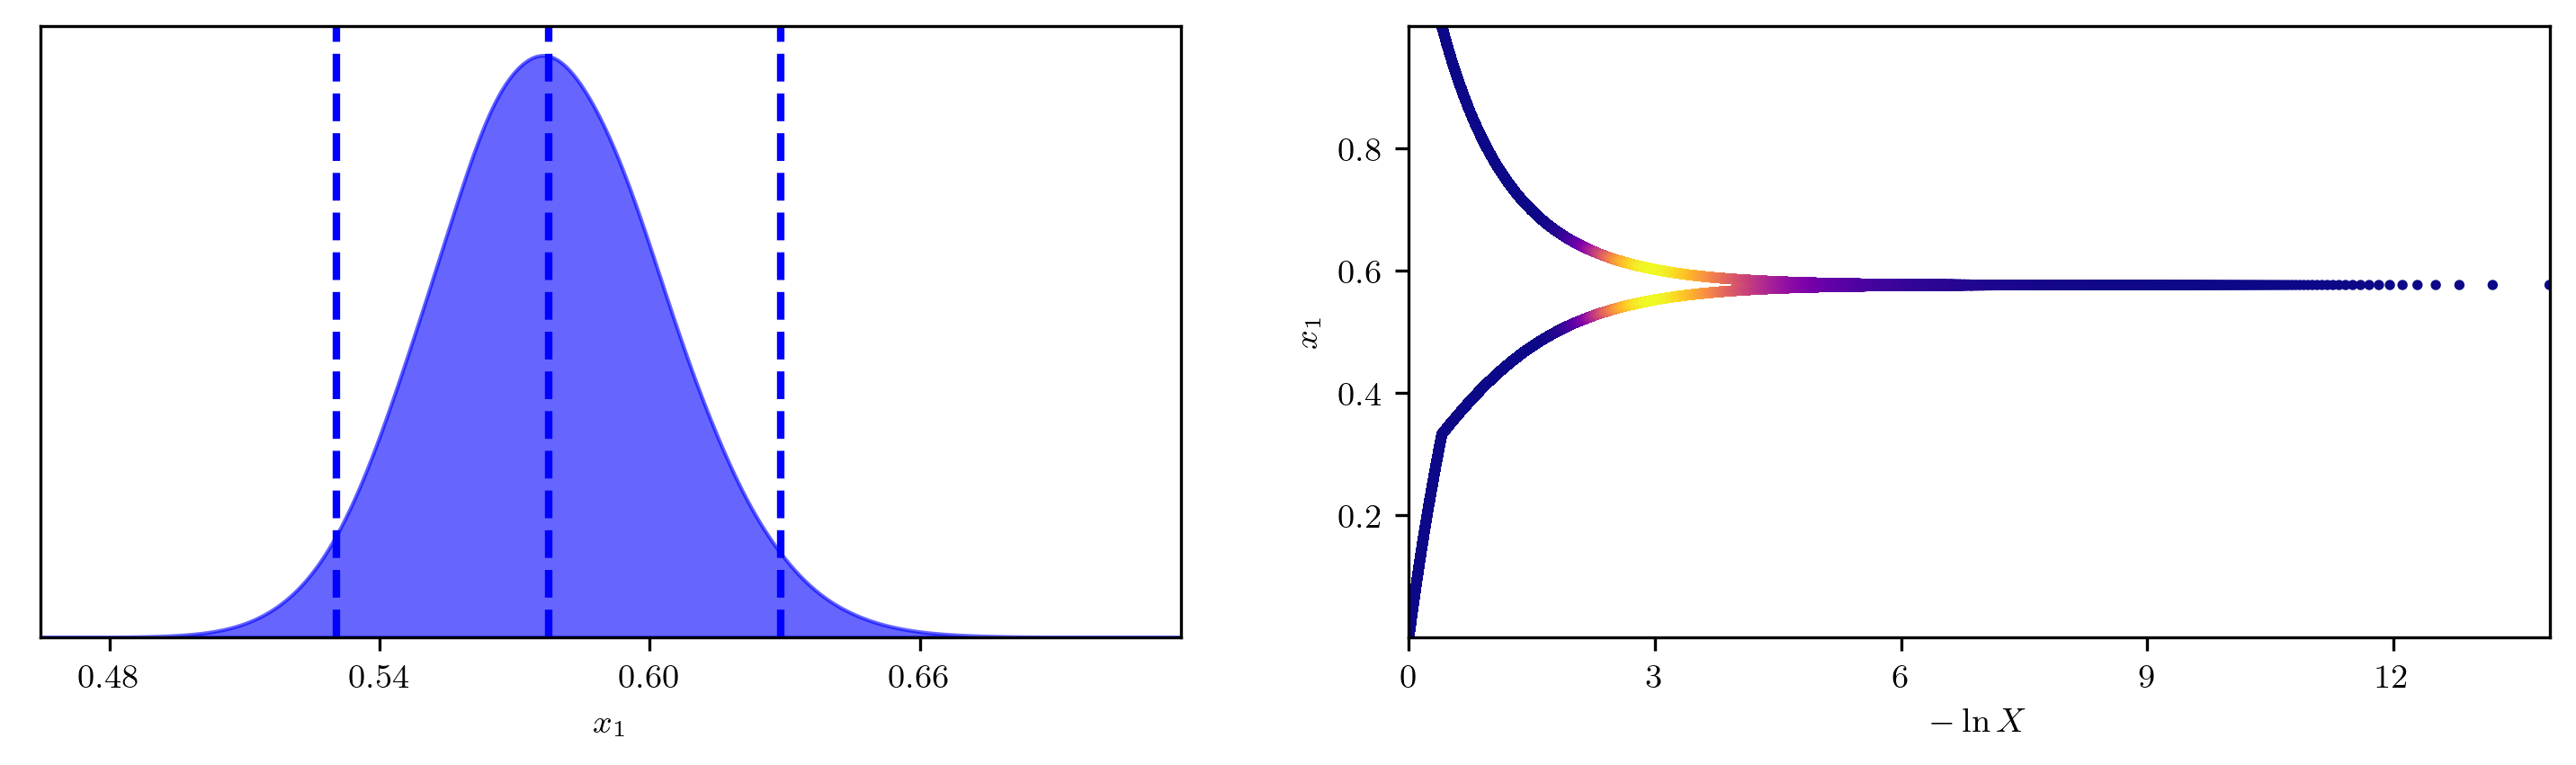

In [77]:
r2fig, r2axes = dyplot.runplot(sresults_no_Lambda, color='black')

t2fig, t2axes = dyplot.traceplot(sresults_no_Lambda)

(1086422,)


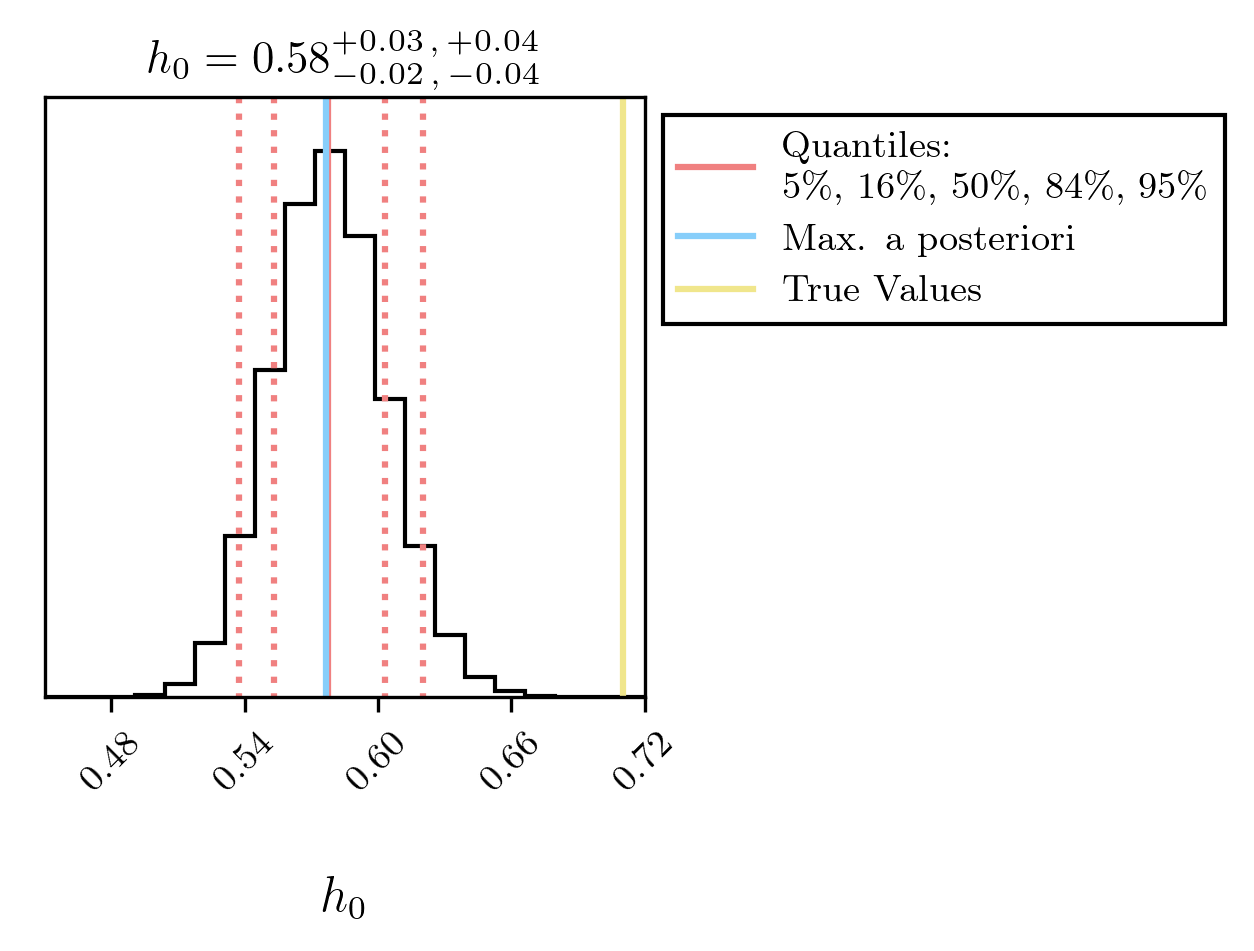

In [99]:
#-------------------------------------------------------------------------
# corner plot  of the nested sampling paramters 

samples_no_Lambda = sresults_no_Lambda.samples  
normalized_weights_no_Lambda = np.exp(sresults_no_Lambda.logwt - sresults_no_Lambda.logz[-1])
samples_equal_no_Lambda = dyfunc.resample_equal(samples_no_Lambda, normalized_weights_no_Lambda)

#-------------------------------------------------------------------------
# create the corner plot setup with the corner python package
# dynesty built-in corner plots: 
# cfig, caxes = dyplot.cornerplot(sresults1)

fig = corner.corner(
    samples_equal_no_Lambda,
    labels=params_latex,
    verbose      = False,
    show_titles  = False,
    title_kwargs = {'fontsize':fontsize},
    label_kwargs = {'fontsize':fontsize, 'rotation':'horizontal'},
    range        = [(0.45,0.72)] # , (0.,1.1)]
)
ax = fig.axes[0]

#-------------------------------------------------------------------------
# compute ranked statistics for the marginals (1D histograms): quantiles

quantiles_no_Lambda = np.zeros((5,n_dim_no_Lambda))
for i in range(n_dim_no_Lambda):
    quantiles_no_Lambda[:,i] = corner.quantile(samples_equal_no_Lambda[:,i], q=[0.05, 0.16, 0.5, 0.84, 0.95])

#-------------------------------------------------------------------------
# print these quantiles results onto the histograms and as sub-titles 

ax.plot([], [], marker='', color='lightcoral', label='Quantiles:\n5\%, 16\%, 50\%, 84\%, 95\%')

ymax , ymin = ax.get_ylim()

ax.vlines(quantiles_no_Lambda[2,:], ymin=ymin, ymax=ymax, color="lightcoral")
ax.vlines(quantiles_no_Lambda[0,:], ymin=ymin, ymax=ymax, color="lightcoral", ls=':')
ax.vlines(quantiles_no_Lambda[1,:], ymin=ymin, ymax=ymax, color="lightcoral", ls=':')
ax.vlines(quantiles_no_Lambda[3,:], ymin=ymin, ymax=ymax, color="lightcoral", ls=':')
ax.vlines(quantiles_no_Lambda[4,:], ymin=ymin, ymax=ymax, color="lightcoral", ls=':')

# corner.overplot_lines(fig, quantiles_no_Lambda[2,:], color="lightcoral")
# corner.overplot_lines(fig, quantiles_no_Lambda[0,:], color="lightcoral", ls=':')
# corner.overplot_lines(fig, quantiles_no_Lambda[1,:], color="lightcoral", ls=':')
# corner.overplot_lines(fig, quantiles_no_Lambda[3,:], color="lightcoral", ls=':')
# corner.overplot_lines(fig, quantiles_no_Lambda[4,:], color="lightcoral", ls=':')

par_name = [r'h_0', r'\Omega_{\Lambda,0}', r'\Omega_{M,0}']
for i in range(n_dim_no_Lambda):
    titles = '$' + par_name[i] + '=' + \
             '{:.2f}'.format(quantiles_no_Lambda[2,i]) + r'^{+' + \
             '{:.2f}'.format(quantiles_no_Lambda[3,i] - quantiles_no_Lambda[2,i]) + r'\, , \,+' + \
             '{:.2f}'.format(quantiles_no_Lambda[4,i] - quantiles_no_Lambda[2,i]) + r'}_{-'      + \
             '{:.2f}'.format(quantiles_no_Lambda[2,i] - quantiles_no_Lambda[1,i]) + r'\, , \,-'  + \
             '{:.2f}'.format(quantiles_no_Lambda[2,i] - quantiles_no_Lambda[0,i]) + r'}$'
    ax.set_title( titles )

par_median_no_Lambda = quantiles_no_Lambda[2,:]

#-------------------------------------------------------------------------

ax.plot([], [], marker='', color='lightskyblue', label='Max. a posteriori')

M_no_Lambda = len(samples_equal_no_Lambda[:,0])
print(samples_equal_no_Lambda[:,0].shape)

samples_logpost_no_Lambda = np.zeros(M_no_Lambda)
for i in range(M_no_Lambda):
    samples_logpost_no_Lambda[i] = log_posterior_no_Lambda( samples_equal_no_Lambda[i,:], z_sample, mu_sample, dmu )

par_MAP_no_Lambda = samples_equal_no_Lambda[np.argmax(samples_logpost_no_Lambda),:] 

# corner.overplot_lines(fig, par_MAP_no_Lambda, color="lightskyblue")
ax.vlines(par_MAP_no_Lambda, ymin=ymin, ymax=ymax, color="lightskyblue")


#-------------------------------------------------------------------------

ax.plot([], [], marker='', color='khaki', label='True Values')

# corner.overplot_lines(fig, [0.7104915227720638, 0.73], color="khaki")
ax.vlines(0.7104915227720638, ymin=ymin, ymax=ymax, color="khaki")

#-------------------------------------------------------------------------
# utility: make legend, save figure:

ax.legend(title_fontsize=9, fontsize=9, frameon=True, framealpha=1, fancybox=False, edgecolor='black', loc=2, bbox_to_anchor=(1,1))

if True:
    fig.savefig('./L18_images/L18_dynesty__Corner_Plot__no_Lambda.pdf', bbox_inches='tight')
    fig.savefig('./L18_images/L18_dynesty__Corner_Plot__no_Lambda.png', bbox_inches='tight')


C:\Users\andre\AppData\Local\Temp\ipykernel_8728\3301643085.py:12: RuntimeWarning: divide by zero encountered in log10
  return 5*(result + np.log10(hyper21) + const3e7)
C:\Users\andre\AppData\Local\Temp\ipykernel_8728\3301643085.py:12: RuntimeWarning: divide by zero encountered in log10
  return 5*(result + np.log10(hyper21) + const3e7)
C:\Users\andre\AppData\Local\Temp\ipykernel_8728\3301643085.py:12: RuntimeWarning: divide by zero encountered in log10
  return 5*(result + np.log10(hyper21) + const3e7)
C:\Users\andre\AppData\Local\Temp\ipykernel_8728\3768071213.py:8: RuntimeWarning: divide by zero encountered in log10
  result_2 = np.log10(2. - 2. * var_z**(-1./2.))


$h_0=0.58, \Omega_{\Lambda,0} = 0.00, \Omega_{M,0} = 1.00\quad $ (Maxima a Posteriori)


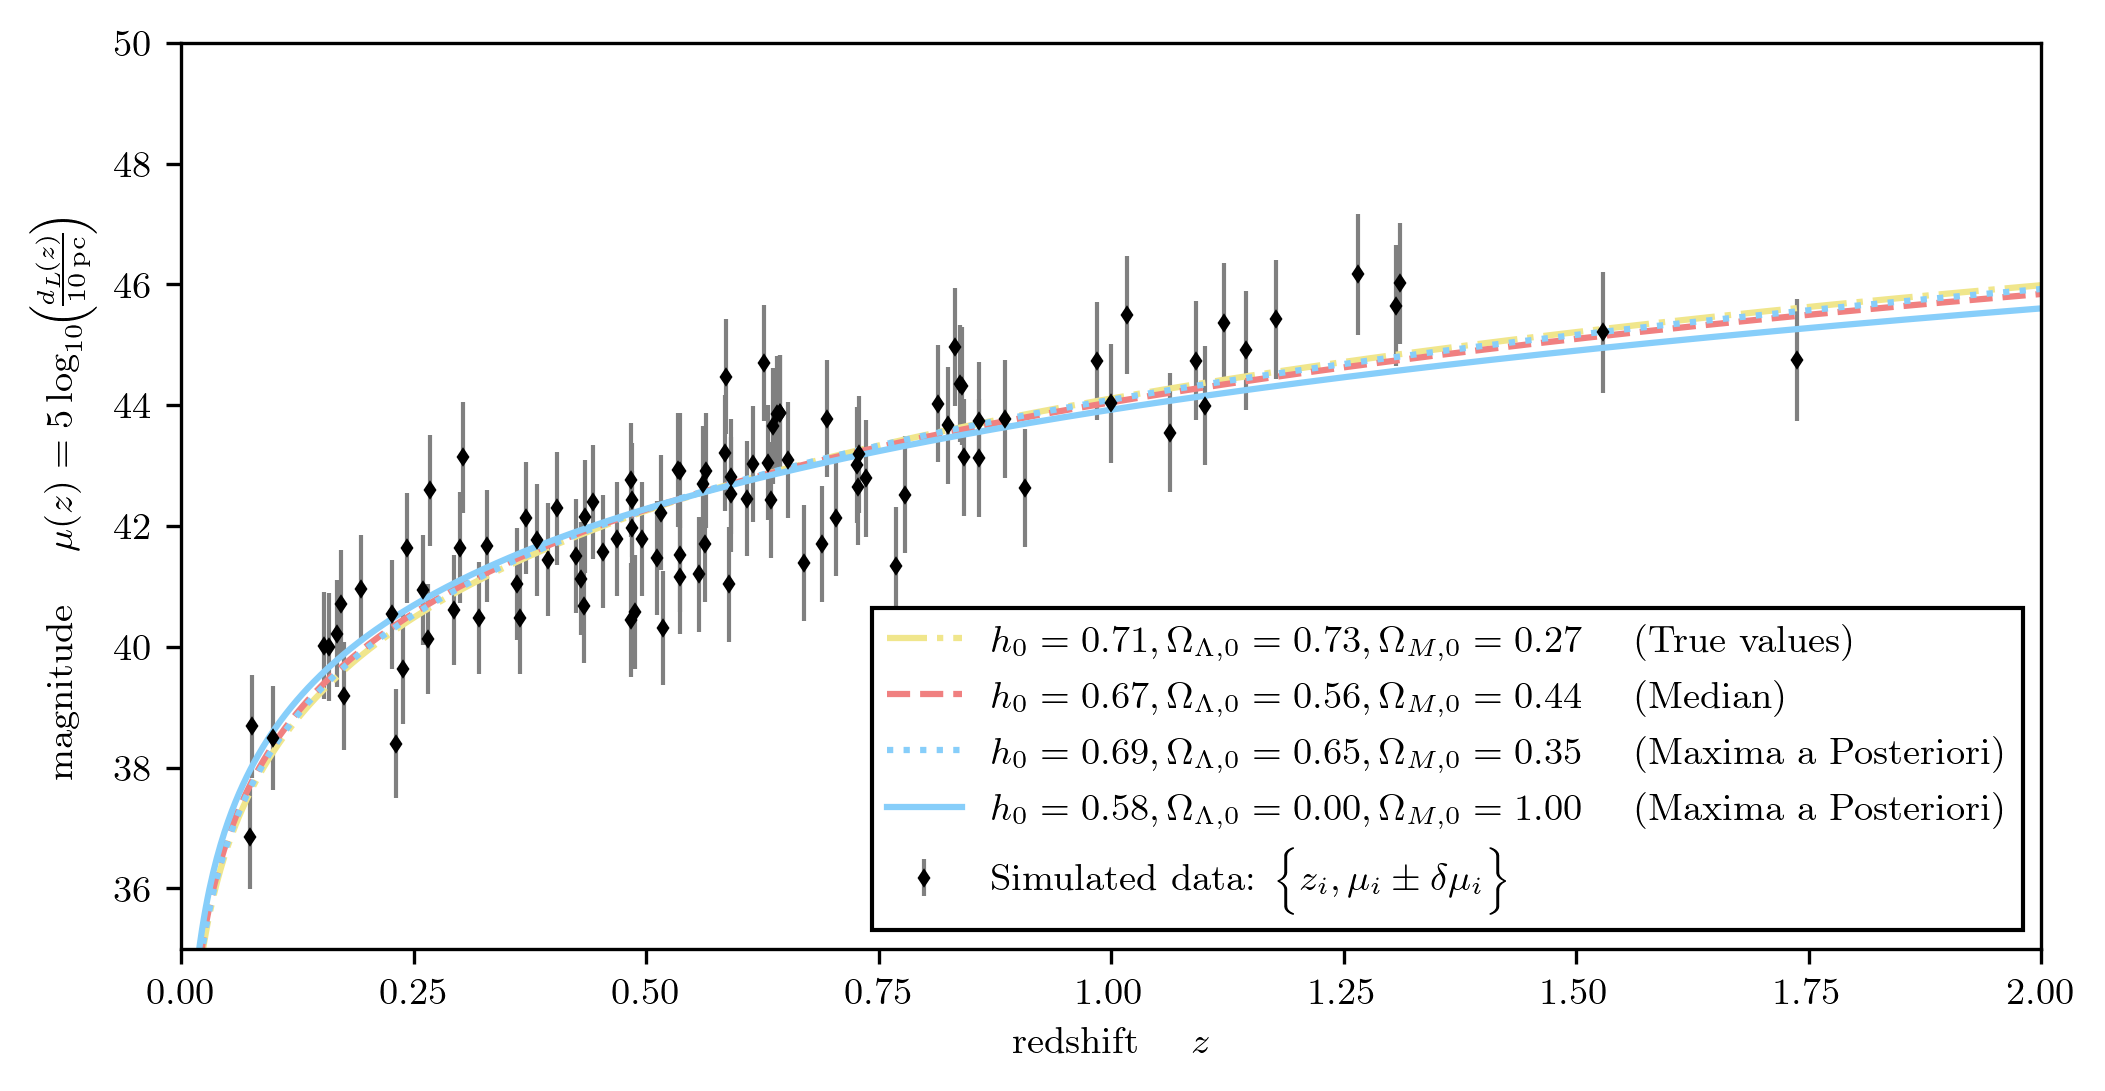

In [105]:
#-------------------------------------------------------------------------
# Visualize the result of both nested sampling fits
#-------------------------------------------------------------------------

fig , ax = plt.subplots(figsize=(8,4))

plt.errorbar(z_sample, mu_sample, dmu, color='black', marker='d', markersize=2, ecolor='gray', ls='', lw=1, label=r'Simulated data: $\big\{z_i , \mu_i \pm \delta \mu_i\big\}$')
plt.xlabel(r"redshift $\quad z$")
plt.ylabel(r"magnitude $\quad \mu(z) = 5 \log_{10}\!\!\left(\!\frac{d_L\!(z)}{10\, \rm pc}\!\right)$")
plt.xlim(0,2)
plt.ylim(35,50)

plt.plot( z_grid, mu_modellino([0.71, 0.73], z=z_grid), ls='-.', color='khaki', label=label_Tru )

plt.plot( z_grid, mu_modellino(par_median, z=z_grid), ls='--', color='lightcoral', label=label_median)

plt.plot( z_grid, mu_modellino(par_MAP, z=z_grid), ls=':', color='lightskyblue', label=label_MAP)

label_MAP_no_Lambda = '$h_0={:.2f}, '.format(par_MAP_no_Lambda[0])
label_MAP_no_Lambda += '\Omega_{\Lambda,0} = 0.00, '
label_MAP_no_Lambda += '\Omega_{M,0} = 1.00'
label_MAP_no_Lambda += '\quad $ (Maxima a Posteriori)'
print(label_MAP_no_Lambda)

plt.plot( z_grid, mu_no_Lambda(par_MAP_no_Lambda, z=z_grid), color='lightskyblue', label=label_MAP_no_Lambda)

#-------------------------------------------------------------------------

ax.legend(loc=4, frameon=True, framealpha=1, fancybox=False, edgecolor='black' )

if True:
    fig.savefig('./L18_images/L18_dynesty__Results_Lambda_and_NoLambda.pdf', bbox_inches='tight')
    fig.savefig('./L18_images/L18_dynesty__Results_Lambda_and_NoLambda.png', bbox_inches='tight')

#-------------------------------------------------------------------------

In [ ]:
#-------------------------------------------------------------------------
# with nested sampling, we can compute the evidence and compare the two models 
# (with/without cosmological constant Lambda)
#-------------------------------------------------------------------------

logZ_yes_Lambda = sresults.logz[-1]
logZ_noo_Lambda = sresults_no_Lambda.logz[-1]
logB = logZ_yes_Lambda - logZ_noo_Lambda
B = np.exp( logB )

print(B, logB)

#-------------------------------------------------------------------------

1.7924670598589623 0.583592916675066


The evidence is inconclusive. 

# Gaussian Process Regression - data driven fit (no model)

In [ ]:
#-------------------------------------------------------------------------
# just a quick investigation on how the gaussian process regression works 
#-------------------------------------------------------------------------

h_kernel = 3
c_kernel = 1
kernel   = kernels.ConstantKernel(c_kernel, (1e-3*c_kernel, 1e3*c_kernel)) * kernels.RBF(h_kernel, (1e-3*h_kernel, 5*h_kernel))

GPR      = GaussianProcessRegressor(kernel=kernel, alpha=dmu**2, random_state=0)

GPR.fit(z_sample[:, np.newaxis], mu_sample)

mu_GPR, dmu_GPR = GPR.predict(z_grid[:, np.newaxis], return_std=True)

print("quick look at kernel params =", GPR.kernel_.theta)

best-fit theta = [6.84740895 1.36058075]


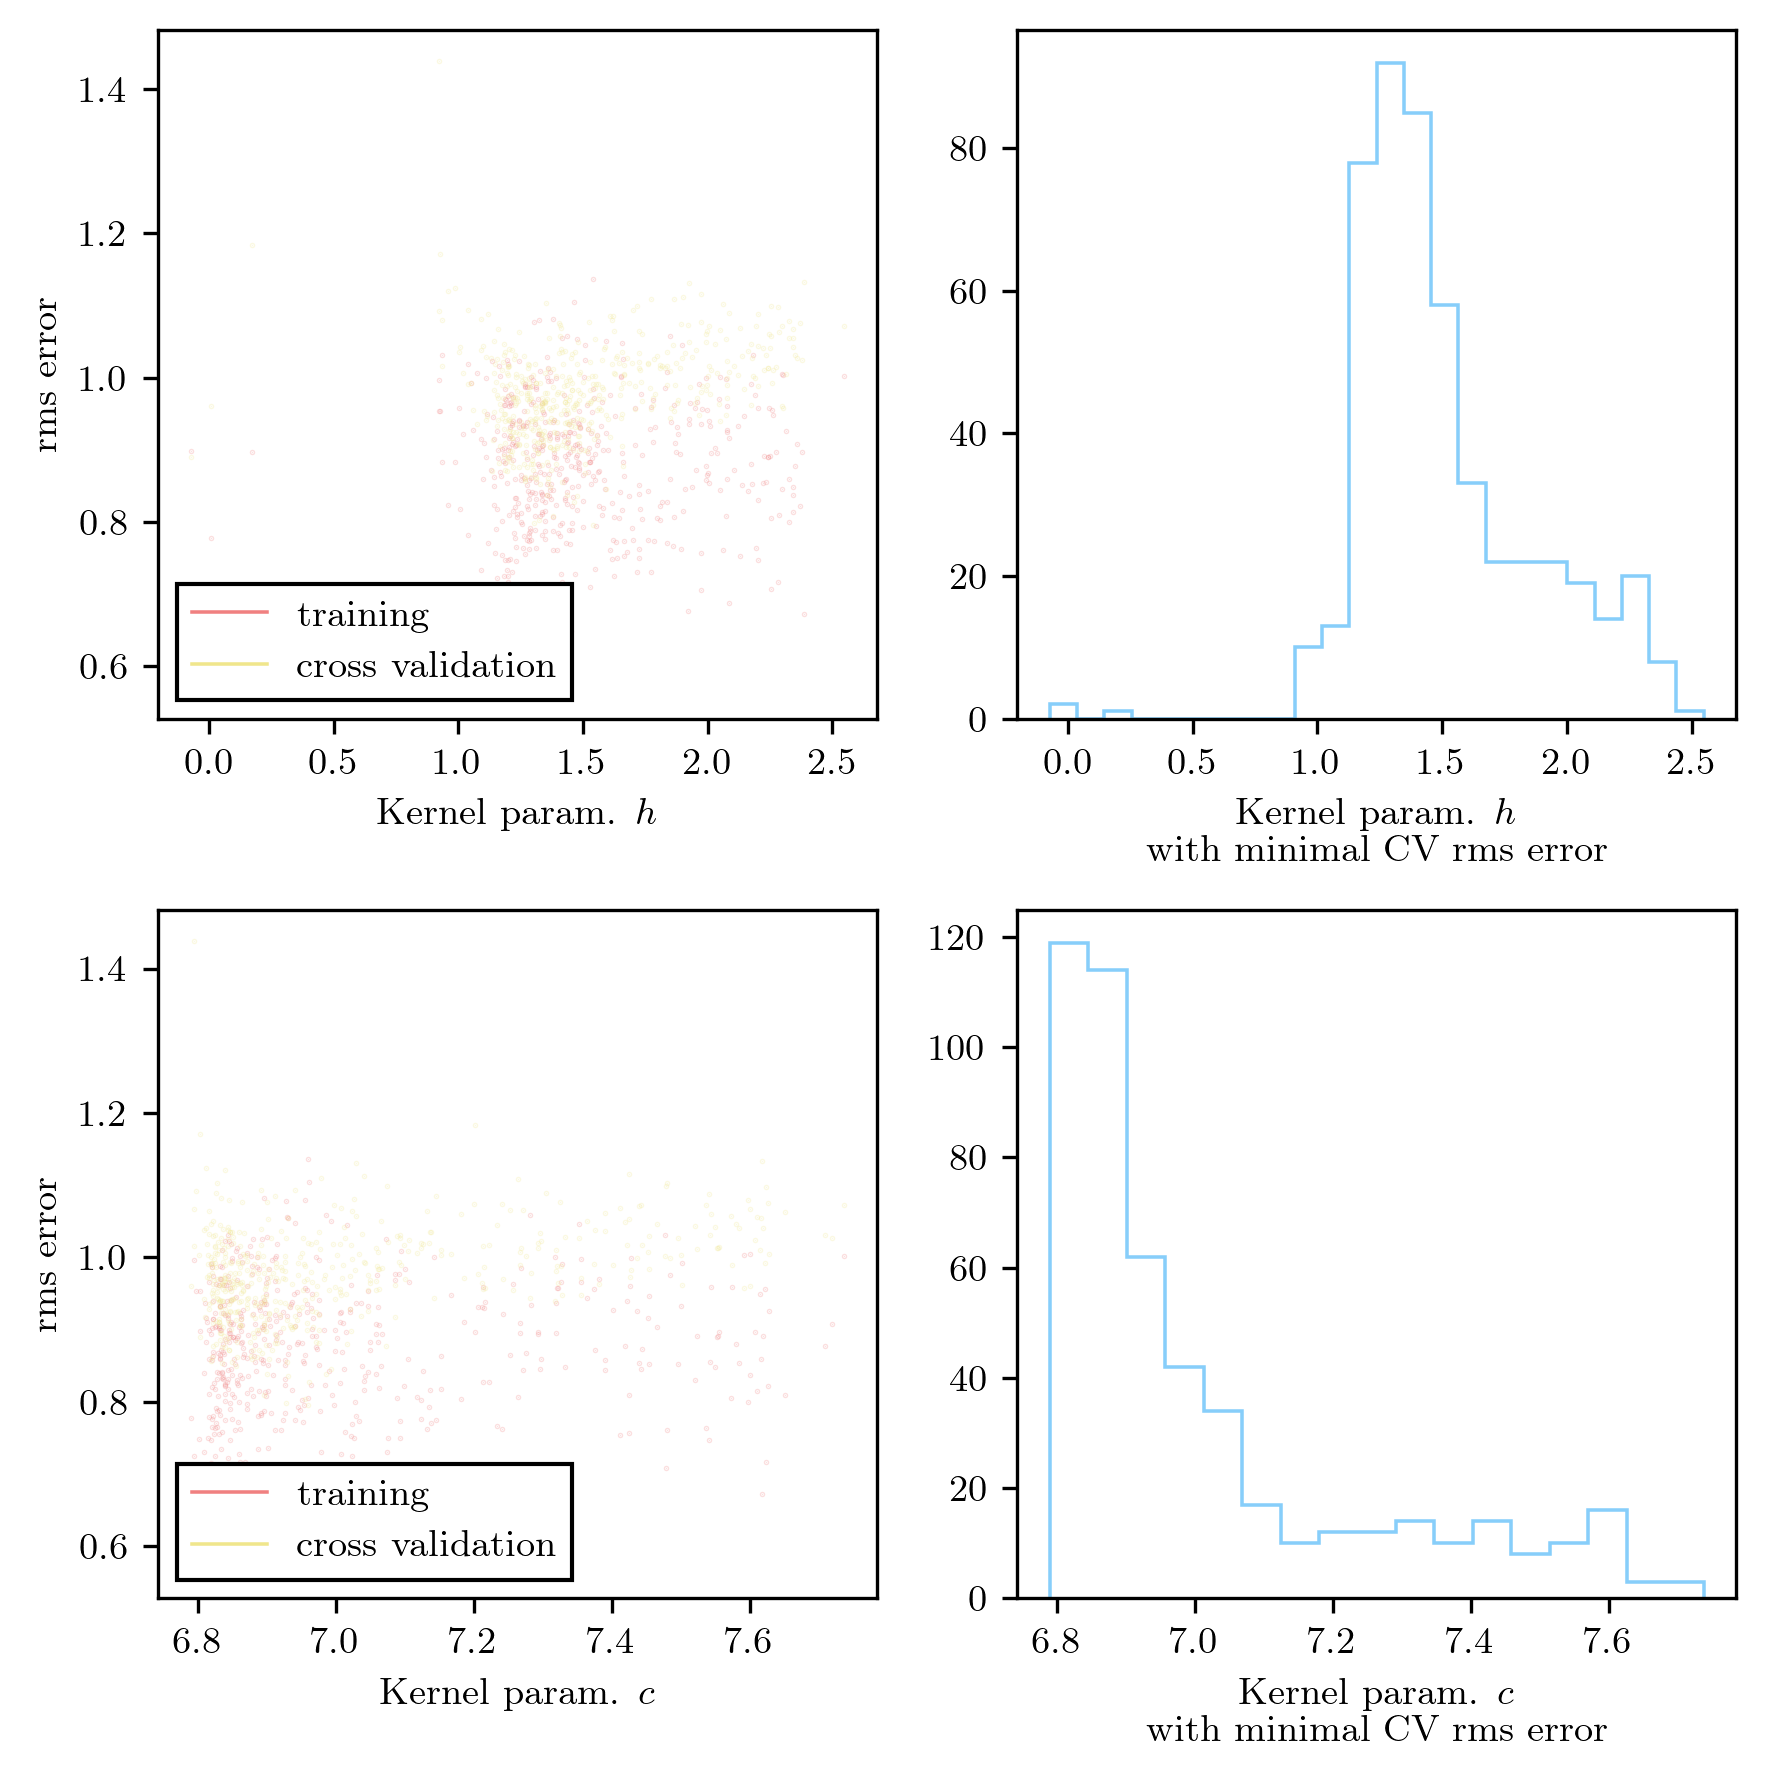

In [ ]:
#-------------------------------------------------------------------------
# determine the best kernel parameters with Cross Validation
#-------------------------------------------------------------------------

fig , ax = plt.subplots(2,2,figsize=(6,6))
ax = ax.reshape(4)

label_ax = ['$h$','','$c$']
for i in [0,2]:
    ax[i].set_xlabel(r'Kernel param. ' + label_ax[i])
    ax[i+1].set_xlabel(r'Kernel param. ' + label_ax[i] + '\nwith minimal CV rms error')
    ax[i].set_ylabel('rms error')
    # ax[i].set_xscale('log')
    # ax[i].set_yscale('log')
    # ax[i].set_xticks(np.logspace(-1,0,10))

mu_grid_lots = []
GPR_lots = []

# k_widths = np.round(np.linspace(1e-2,1e1,1000), 2)
# c_widths = np.round(np.linspace(1e-2,1e2,1000), 2)

ax[0].plot([], [], lw=0.85, color='lightcoral', label='training')
ax[0].plot([], [], lw=0.85, color='khaki', label='cross validation')
ax[2].plot([], [], lw=0.85, color='lightcoral', label='training')
ax[2].plot([], [], lw=0.85, color='khaki', label='cross validation')

N_CV = 500

training_err = np.zeros(N_CV)
crossval_err = np.zeros(N_CV)

h_kernel_widths = np.zeros(N_CV)
c_kernel_widths = np.zeros(N_CV)

h_kernel = 3
c_kernel = 1

for j in range(N_CV):

    z_train, z_test, mu_train, mu_test, dmu_train, dmu_test = train_test_split(z_sample, mu_sample, dmu, test_size=0.65)

    N_train = len(z_train)
    N_test  = len(z_test)
    
    kernel = kernels.ConstantKernel(c_kernel, (1e-3*c_kernel, 1e4*c_kernel)) * kernels.RBF(h_kernel, (1e-3*h_kernel, 5*h_kernel))
    GPR = GaussianProcessRegressor(kernel=kernel, alpha=dmu_train**2, random_state=0)
    GPR_lots.append(GPR)

    mu_grid_train = []

    GPR.fit(z_train[:,np.newaxis], mu_train)

    mu_grid_j = GPR.predict(z_grid[:,np.newaxis])
    mu_grid_lots.append(mu_grid_j)

    mu_train_j = GPR_lots[j].predict(z_train[:,np.newaxis])
    mu_test_j  = GPR_lots[j].predict(z_test[:,np.newaxis])

    training_err[j] = np.sqrt( np.sum( (mu_train_j - mu_train)**2 / N_train) )
    crossval_err[j] = np.sqrt( np.sum( (mu_test_j  - mu_test)**2  / N_test) )

    c_kernel_j , h_kernel_j =  GPR.kernel_.theta

    h_kernel_widths[j] = h_kernel_j
    c_kernel_widths[j] = c_kernel_j

ax[0].scatter(h_kernel_widths, training_err, marker='o', s=0.1, alpha=0.25, color='lightcoral')
ax[0].scatter(h_kernel_widths, crossval_err, marker='o', s=0.1, alpha=0.25, color='khaki')
ax[2].scatter(c_kernel_widths, training_err, marker='o', s=0.1, alpha=0.25, color='lightcoral')
ax[2].scatter(c_kernel_widths, crossval_err, marker='o', s=0.1, alpha=0.25, color='khaki')

# bins = np.round(np.linspace(1,10,30),0)
_ = fancyhist(h_kernel_widths, ax=ax[1], bins='knuth', histtype='step', density=False, color='lightskyblue', lw=0.85) #np.logspace(-2,0,300)
_ = fancyhist(c_kernel_widths, ax=ax[3], bins='knuth', histtype='step', density=False, color='lightskyblue', lw=0.85) #np.logspace(-2,0,300)

#-------------------------------------------------------------------------

_ = ax[0].legend(frameon=True, framealpha=1, fancybox=False, edgecolor='black', loc=3)
_ = ax[2].legend(frameon=True, framealpha=1, fancybox=False, edgecolor='black', loc=3)

fig.tight_layout()

if False:
    fig.savefig('./L18_images/L18__GauusProcRegr__CrossValidation.pdf', bbox_inches='tight')
    fig.savefig('./L18_images/L18__GauusProcRegr__CrossValidation.png', bbox_inches='tight')

#-------------------------------------------------------------------------


In [ ]:
#-------------------------------------------------------------------------
# with the Cross Validated kernel params, run the Gaussian Process Regression
#-------------------------------------------------------------------------

best_h_kernel = h_kernel_widths[np.nanargmin(crossval_err)]
best_c_kernel = c_kernel_widths[np.nanargmin(crossval_err)]
best_kernel   = kernels.ConstantKernel(c_kernel, (c_kernel, c_kernel)) * kernels.RBF(h_kernel, (h_kernel, h_kernel))
best_gpr      = GaussianProcessRegressor(kernel=kernel, alpha=dmu**2, random_state=0)

print(dmu.shape)
print(z_sample.shape)
print(mu_sample.shape)

best_gpr.fit(z_sample[:, np.newaxis], mu_sample)
mu_GPR, dmu_GPR = GPR.predict(z_grid[:, np.newaxis], return_std=True)
print("best-fit kernel params =", GPR.kernel_.theta)



(100,)
(100,)
(100,)
best-fit theta = [6.85301421 1.43152608]


C:\Users\andre\AppData\Local\Temp\ipykernel_8728\3942894783.py:12: RuntimeWarning: divide by zero encountered in log10
  return 5*(result + np.log10(hyper21) + const3e7)
C:\Users\andre\AppData\Local\Temp\ipykernel_8728\3942894783.py:12: RuntimeWarning: divide by zero encountered in log10
  return 5*(result + np.log10(hyper21) + const3e7)
C:\Users\andre\AppData\Local\Temp\ipykernel_8728\3942894783.py:12: RuntimeWarning: divide by zero encountered in log10
  return 5*(result + np.log10(hyper21) + const3e7)


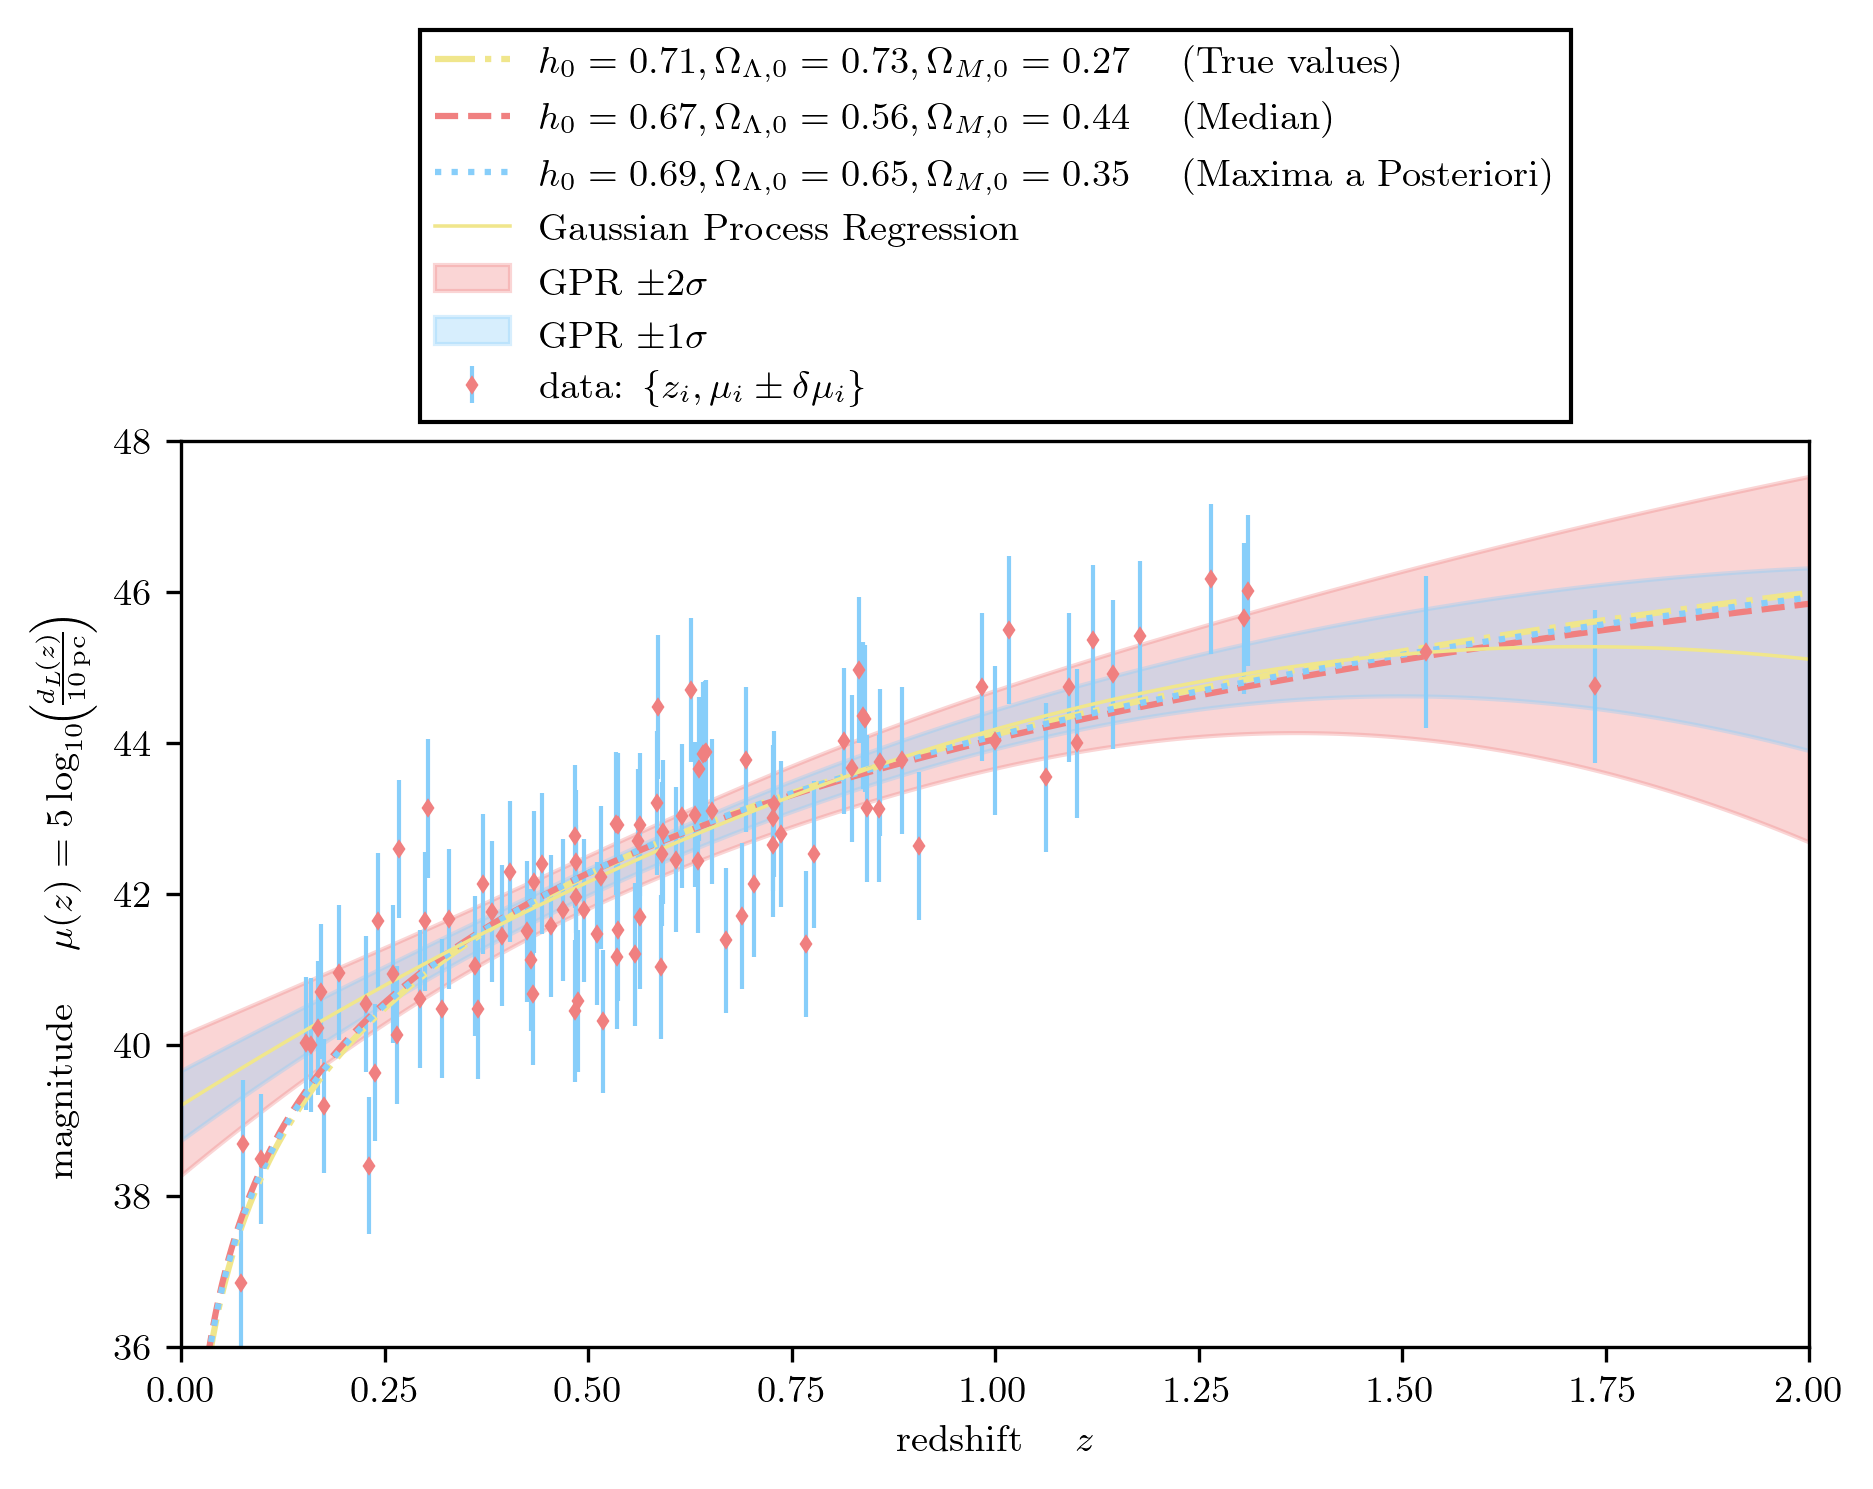

In [ ]:
#-------------------------------------------------------------------------
# Plot the best fit curve from GPR with sigma intervals 
# (and compare it to the theory-informed model)
#-------------------------------------------------------------------------

fig , ax = plt.subplots(figsize=(7,4))


ax.errorbar(z_sample, mu_sample, dmu, color='lightcoral', marker='d', markersize=2, ecolor='lightskyblue', ls='', lw=1, label='data: $\{z_i, \mu_i \pm \delta\mu_i\}$')

ax.set_xlabel(r"redshift $\quad z$")
ax.set_ylabel(r"magnitude $\quad \mu(z) = 5 \log_{10}\!\!\left(\!\frac{d_L\!(z)}{10\, \rm pc}\!\right)$")
ax.set_xlim(0,2)
ax.set_ylim(36,48)

plt.plot( z_grid, mu_modellino([0.71, 0.73], z=z_grid), ls='-.', color='khaki', label=label_Tru )
plt.plot( z_grid, mu_modellino(par_median, z=z_grid), ls='--', color='lightcoral', label=label_median)
plt.plot( z_grid, mu_modellino(par_MAP, z=z_grid), ls=':', color='lightskyblue', label=label_MAP)

ax.plot(z_grid, mu_GPR, '-', color='khaki', lw=0.85, label='Gaussian Process Regression')
ax.fill_between(z_grid, mu_GPR - 2 * dmu_GPR, mu_GPR + 2 * dmu_GPR, alpha=0.33, color='lightcoral', label='GPR $\pm 2\sigma$ ')
ax.fill_between(z_grid, mu_GPR - 1 * dmu_GPR, mu_GPR + 1 * dmu_GPR, alpha=0.33, color='lightskyblue', label='GPR $\pm 1\sigma$ ')

# ax.errorbar(x_grid, mu_GPR, dmu_GPR, fmt='.k', ms=6)

_ = ax.legend(frameon=True, framealpha=1, fancybox=False, edgecolor='black', loc='lower center', bbox_to_anchor=(0.5,1.0))

#-------------------------------------------------------------------------

if False:
    fig.savefig('./L18_images/L18_GaussProcRegr__Best_Fit_CrossValidated.pdf', bbox_inches='tight')
    fig.savefig('./L18_images/L18_GaussProcRegr__Best_Fit_CrossValidated.png', bbox_inches='tight')


# Cloning - upsampling the dataset

In [119]:
N_dataset      = len(z_sample)
N_upsampling   = int(10*N_dataset)
N_dynesty_LCDM = samples_equal.shape[0]

z_upsampling_GPR  = stats.uniform(loc=0,scale=2).rvs(size=N_upsampling)
z_upsampling_GPR = z_upsampling_GPR[:,np.newaxis]

mu_temp_GPR, dmu_temp_GPR = GPR.predict( z_upsampling_GPR, return_std=True)

mu_upsampling_GPR = np.zeros_like(z_upsampling_GPR)

for i in range(N_upsampling):
    # extract mu from a normal distribution with
    ## mean = gpr prediction for mu(z)
    ## stdd = gpr 1sigma for mu(z)
    mu_upsampling_GPR[i] = stats.norm(loc=mu_temp_GPR[i],scale=dmu_temp_GPR[i]).rvs()

z_upsampling_LCDM  = stats.uniform(loc=0,scale=2).rvs(size=N_upsampling)
mu_upsampling_LCDM = np.zeros_like(z_upsampling_LCDM)

for i, z_i in enumerate(z_upsampling_LCDM):
    # pick one of the params sampled by dynesty
    # note that it will follow the param distrib!
    par_i = samples_equal[ np.random.choice(N_dynesty_LCDM) ]
    mu_upsampling_LCDM[i] = mu_modellino(par_i, z_i)


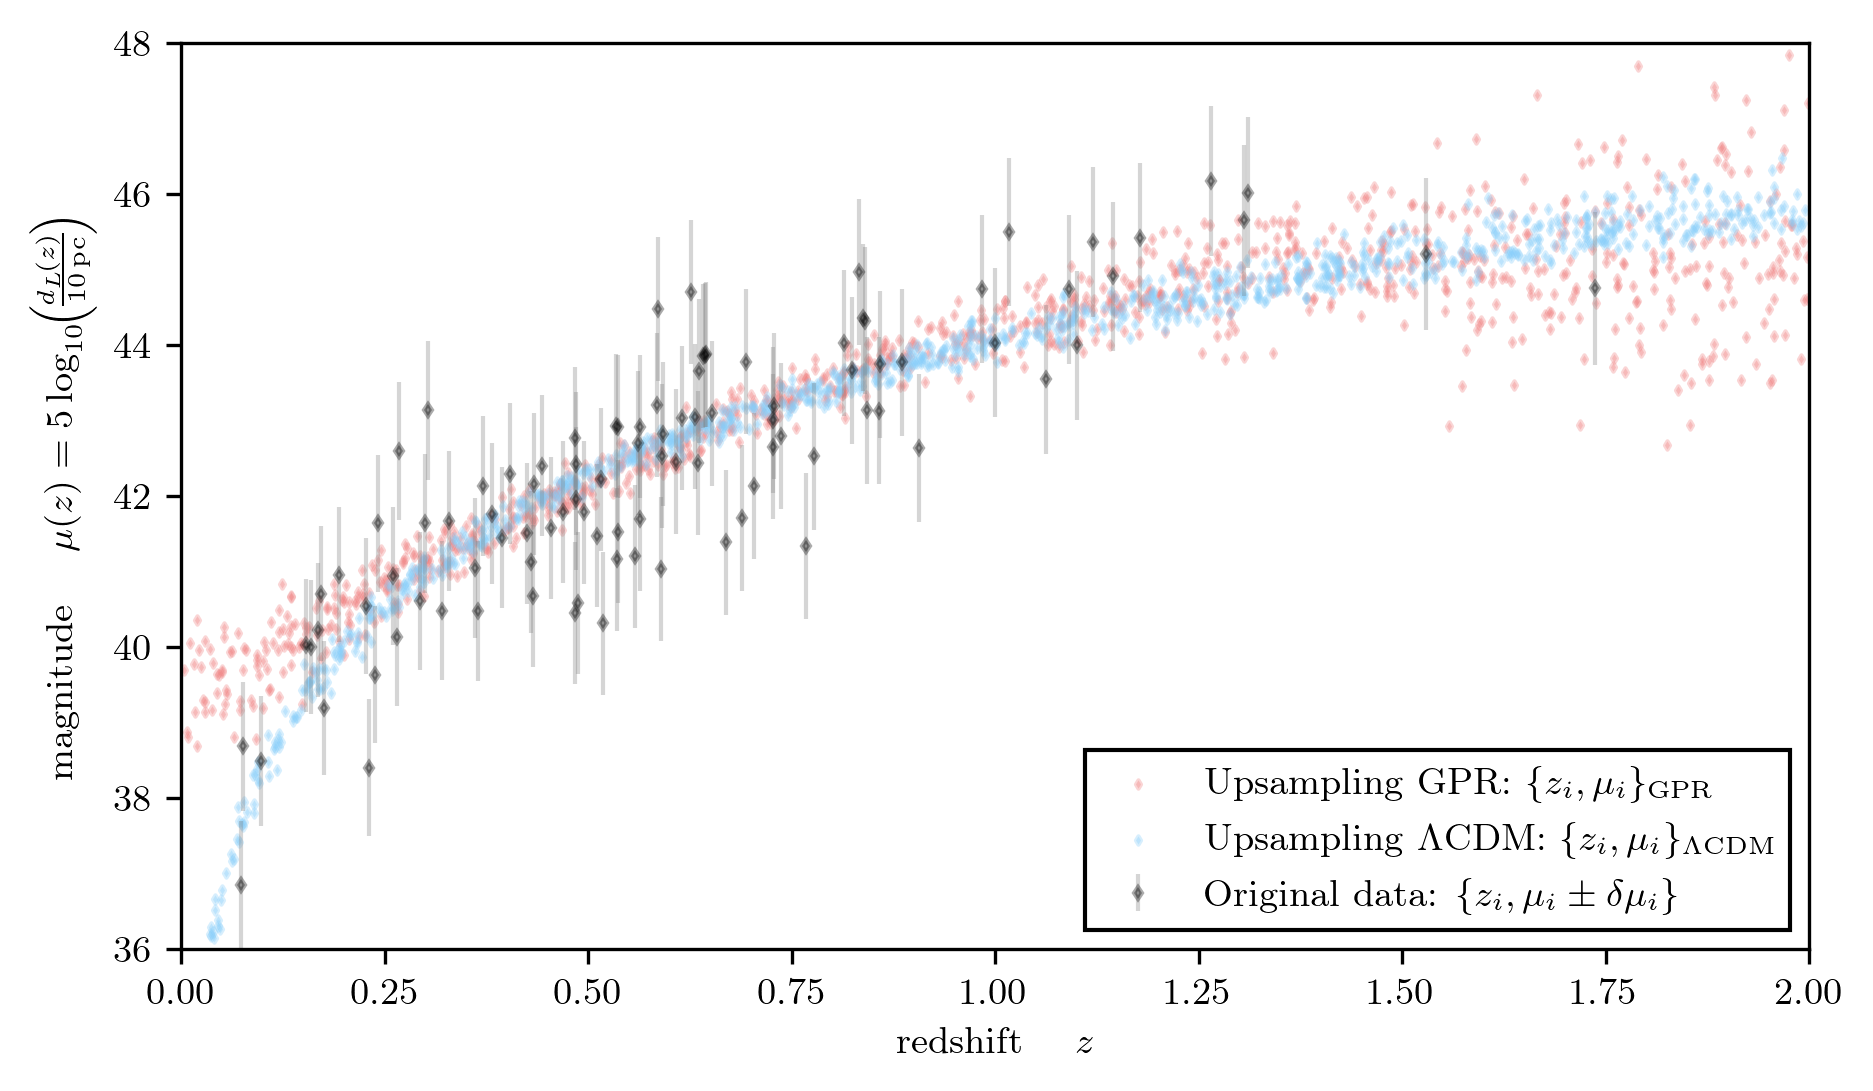

In [129]:
#-------------------------------------------------------------------------
# Plot the best fit curve from GPR with sigma intervals 
# (and compare it to the theory-informed model)
#-------------------------------------------------------------------------

fig , ax = plt.subplots(figsize=(7,4))


ax.errorbar(z_sample, mu_sample, dmu, color='black', marker='d', markersize=2, alpha=0.33, ecolor='gray', ls='', lw=1, label='Original data: $\{z_i, \mu_i \pm \delta\mu_i\}$')

ax.set_xlabel(r"redshift $\quad z$")
ax.set_ylabel(r"magnitude $\quad \mu(z) = 5 \log_{10}\!\!\left(\!\frac{d_L\!(z)}{10\, \rm pc}\!\right)$")
ax.set_xlim(0,2)
ax.set_ylim(36,48)

ax.scatter(z_upsampling_GPR, mu_upsampling_GPR, color='lightcoral', marker='d', s=2, alpha=0.33, label=r'Upsampling GPR: $\{z_i, \mu_i \}_{\rm GPR}$')

ax.scatter(z_upsampling_LCDM, mu_upsampling_LCDM, color='lightskyblue', marker='d', s=2, alpha=0.33, label=r'Upsampling $\Lambda$CDM: $\{z_i, \mu_i \}_{\rm \Lambda CDM}$')

_ = ax.legend(frameon=True, framealpha=1, fancybox=False, edgecolor='black', loc=4)

#-------------------------------------------------------------------------

if True:
    fig.savefig('./L18_images/L18_Upsampling_LCDM+GPR.pdf', bbox_inches='tight')
    fig.savefig('./L18_images/L18_Upsampling_LCDM+GPR.png', bbox_inches='tight')


# Recap of part I results

In [19]:
#-------------------------------------------------------------------------
# define the regressio models (polynomials of various orders)
#-------------------------------------------------------------------------

pol_degrees = range(1,6)
pol_regr = []
theta = []
mu_pred = []
for d in pol_degrees:
    pol_regr.append(PolynomialRegression(d))

[2, 4, 2, 2, 3, 2, 2, 4, 4, 5, 2, 3, 2, 2, 2, 1, 2, 2, 4, 2, 4, 4, 4, 2, 4, 5, 4, 5, 5, 1, 2, 4, 4, 2, 2, 2, 4, 1, 5, 1, 1, 4, 2, 2, 1, 2, 1, 2, 3, 4, 2, 2, 2, 4, 4, 2, 2, 2, 4, 2, 4, 2, 5, 2, 2, 2, 5, 4, 5, 2, 2, 5, 2, 2, 1, 2, 2, 2, 2, 2, 2, 5, 4, 4, 2, 2, 2, 2, 2, 2, 2, 2, 2, 3, 2, 2, 2, 3, 4, 2, 1, 2, 2, 4, 2, 4, 5, 2, 5, 5, 2, 2, 2, 4, 2, 4, 4, 2, 4, 2, 2, 4, 4, 2, 5, 2, 4, 3, 4, 2, 2, 4, 5, 4, 2, 2, 2, 2, 5, 5, 5, 5, 2, 2, 4, 2, 1, 4, 4, 4, 2, 2, 3, 5, 2, 2, 2, 2, 2, 4, 2, 1, 2, 2, 1, 5, 5, 5, 4, 4, 5, 2, 2, 2, 2, 5, 5, 2, 2, 4, 2, 4, 2, 5, 2, 2, 2, 4, 5, 2, 2, 4, 4, 2, 4, 4, 2, 2, 4, 4, 2, 5, 4, 5, 2, 2, 4, 1, 2, 2, 3, 4, 2, 4, 2, 5, 2, 4, 4, 2, 2, 2, 2, 2, 5, 4, 2, 2, 2, 5, 2, 4, 2, 2, 2, 2, 2, 4, 5, 3, 4, 4, 4, 2, 2, 2, 2, 2, 2, 2, 2, 1, 5, 2, 2, 2, 2, 2, 2, 5, 2, 2, 2, 2, 2, 2, 4, 2, 2, 2, 2, 4, 4, 2, 5, 2, 5, 2, 2, 5, 2, 4, 4, 2, 2, 1, 2, 1, 2, 4, 2, 5, 2, 2, 2, 2, 5, 2, 5, 2, 4, 5, 2, 2, 5, 4, 2, 2, 5, 3, 2, 1, 5, 4, 4, 4, 2, 5, 2, 4, 2, 4, 4, 3, 2, 2, 2, 2, 4, 2, 4, 2, 2, 

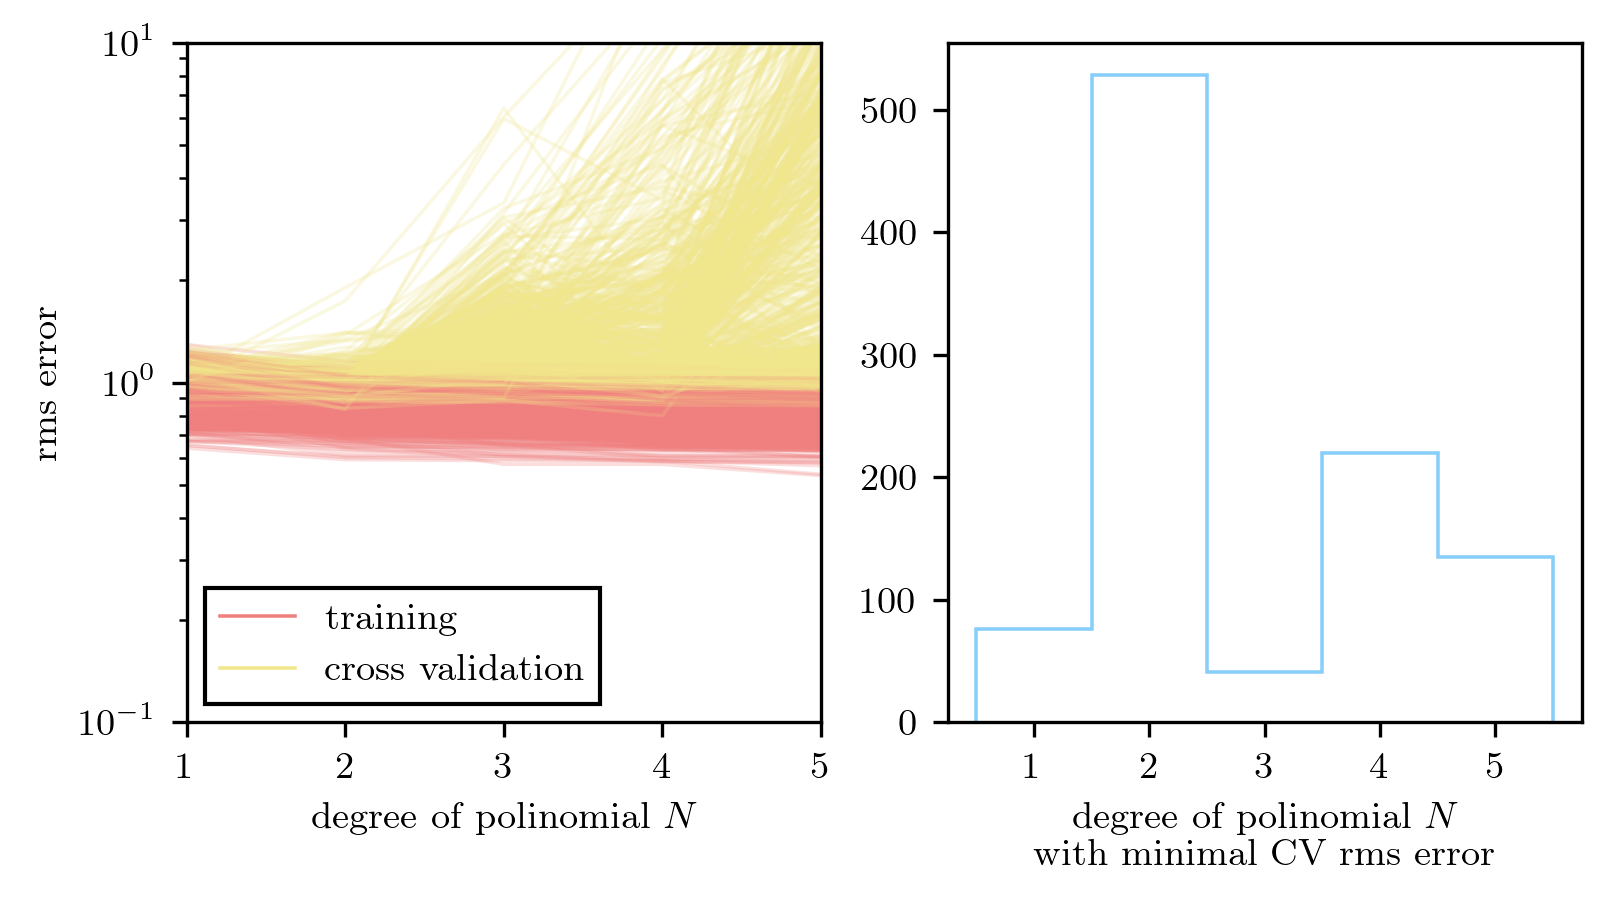

In [20]:
#-------------------------------------------------------------------------
# Now do the Cross Validation 1000 times to compute the best polynomial degree
# as the mode (most recurring result) and for this mode, average the best fits
#-------------------------------------------------------------------------

fig , ax = plt.subplots(1,2,figsize=(6,3))

ax[0].set_xlabel(r'degree of polinomial $N$')
ax[0].set_ylabel('rms error')
ax[0].set_xlim(1,5)
ax[0].set_yscale('log')
ax[0].set_ylim(1e-1,1e1)

ax[1].set_xticks(np.linspace(1,5,5))
ax[1].set_xlabel(r'degree of polinomial $N$'+'\nwith minimal CV rms error')

best_deg_CV_lots = []
best_theta_CV_lots = []
mu_grid_lots = []

ax[0].plot([], [], lw=0.85, color='lightcoral', label='training')
ax[0].plot([], [], lw=0.85, color='khaki', label='cross validation')

for j in range(1000):

    z_train, z_test, mu_train, mu_test, dmu_train, dmu_test = train_test_split(z_sample, mu_sample, dmu, test_size=0.65)

    N_train = len(z_train)
    N_test  = len(z_test)

    pol_degrees = range(1,6)
    pol_regr = []

    for d in pol_degrees:
        pol_regr.append(PolynomialRegression(d))

    training_err = np.zeros(len(pol_degrees))
    crossval_err = np.zeros(len(pol_degrees))

    theta_train = []
    mu_grid_train = []

    for i in range(5):

        pol_regr[i].fit(z_train[:,np.newaxis], mu_train, dmu_train)

        theta_i = pol_regr[i].coef_
        theta_train.append(theta_i)

        mu_grid_i = pol_regr[i].predict(z_grid[:,np.newaxis])
        mu_grid_train.append(mu_grid_i)

        mu_train_i = pol_regr[i].predict(z_train[:,np.newaxis])
        mu_test_i  = pol_regr[i].predict(z_test[:,np.newaxis])

        training_err[i] = np.sqrt( np.sum( (mu_train_i - mu_train)**2 / N_train) )
        crossval_err[i] = np.sqrt( np.sum( (mu_test_i  - mu_test)**2  / N_test) )
    
    ax[0].plot(pol_degrees, training_err, alpha=0.25, lw=0.85, color='lightcoral')
    ax[0].plot(pol_degrees, crossval_err, alpha=0.25, lw=0.85, color='khaki')

    best_deg = pol_degrees[np.argmin(crossval_err)]
    best_deg_CV_lots.append(best_deg)

    best_pol_regr = PolynomialRegression(best_deg)

    # train data only
    best_pol_regr.fit(z_train[:,np.newaxis], mu_train, dmu_train)

    best_theta_tr = best_pol_regr.coef_
    best_theta_CV_lots.append(best_theta_tr)
    
    mu_grid_tr = best_pol_regr.predict(z_grid[:,np.newaxis])
    mu_grid_lots.append(mu_grid_tr)

_ = fancyhist(best_deg_CV_lots, ax=ax[1], bins=np.linspace(0.5,5.5,6), histtype='step', density=False, color='lightskyblue', lw=0.85)

_ = ax[0].legend(frameon=True, framealpha=1, fancybox=False, edgecolor='black', loc=3)

print(best_deg_CV_lots)

best_deg_CV = stats.mode(best_deg_CV_lots).mode[0]     # weird syntax but ok

In [21]:
#-------------------------------------------------------------------------
# Organize results from multiple cross validations

print('The best degree for polynomial fitting is {:d}'.format(best_deg_CV))

best_deg_CV_lots = np.array(best_deg_CV_lots)
print(best_deg_CV_lots.shape)

best_theta_CV_lots = np.array(best_theta_CV_lots)
print(best_theta_CV_lots.shape)

mu_grid_lots = np.array(mu_grid_lots)
print(mu_grid_lots.shape)

#-------------------------------------------------------------------------
# select only the training-validation splits with N_polynomial_best=2

index = best_deg_CV_lots == best_deg_CV
# print(index)

N_best_degs = len(best_deg_CV_lots[index])
print('The number of fits we have done with {:d} is {:d}'.format(best_deg_CV, N_best_degs))

mu_grid_onlybest = np.copy(mu_grid_lots[index,:])
print(mu_grid_onlybest.shape)

mu_grid_onlybest_avg = np.average(mu_grid_onlybest, axis=0)
print(mu_grid_onlybest_avg.shape)

best_theta_onlybest = np.array(best_theta_CV_lots[index])
best_theta_onlybest_avg = np.average(best_theta_onlybest)

#-------------------------------------------------------------------------


The best degree for polynomial fitting is 2
(1000,)
(1000,)
(1000, 1000)
The number of fits we have done with 2 is 528
(528, 1000)
(1000,)


C:\Users\andre\AppData\Local\Temp\ipykernel_8728\3666412722.py:9: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  best_theta_CV_lots = np.array(best_theta_CV_lots)


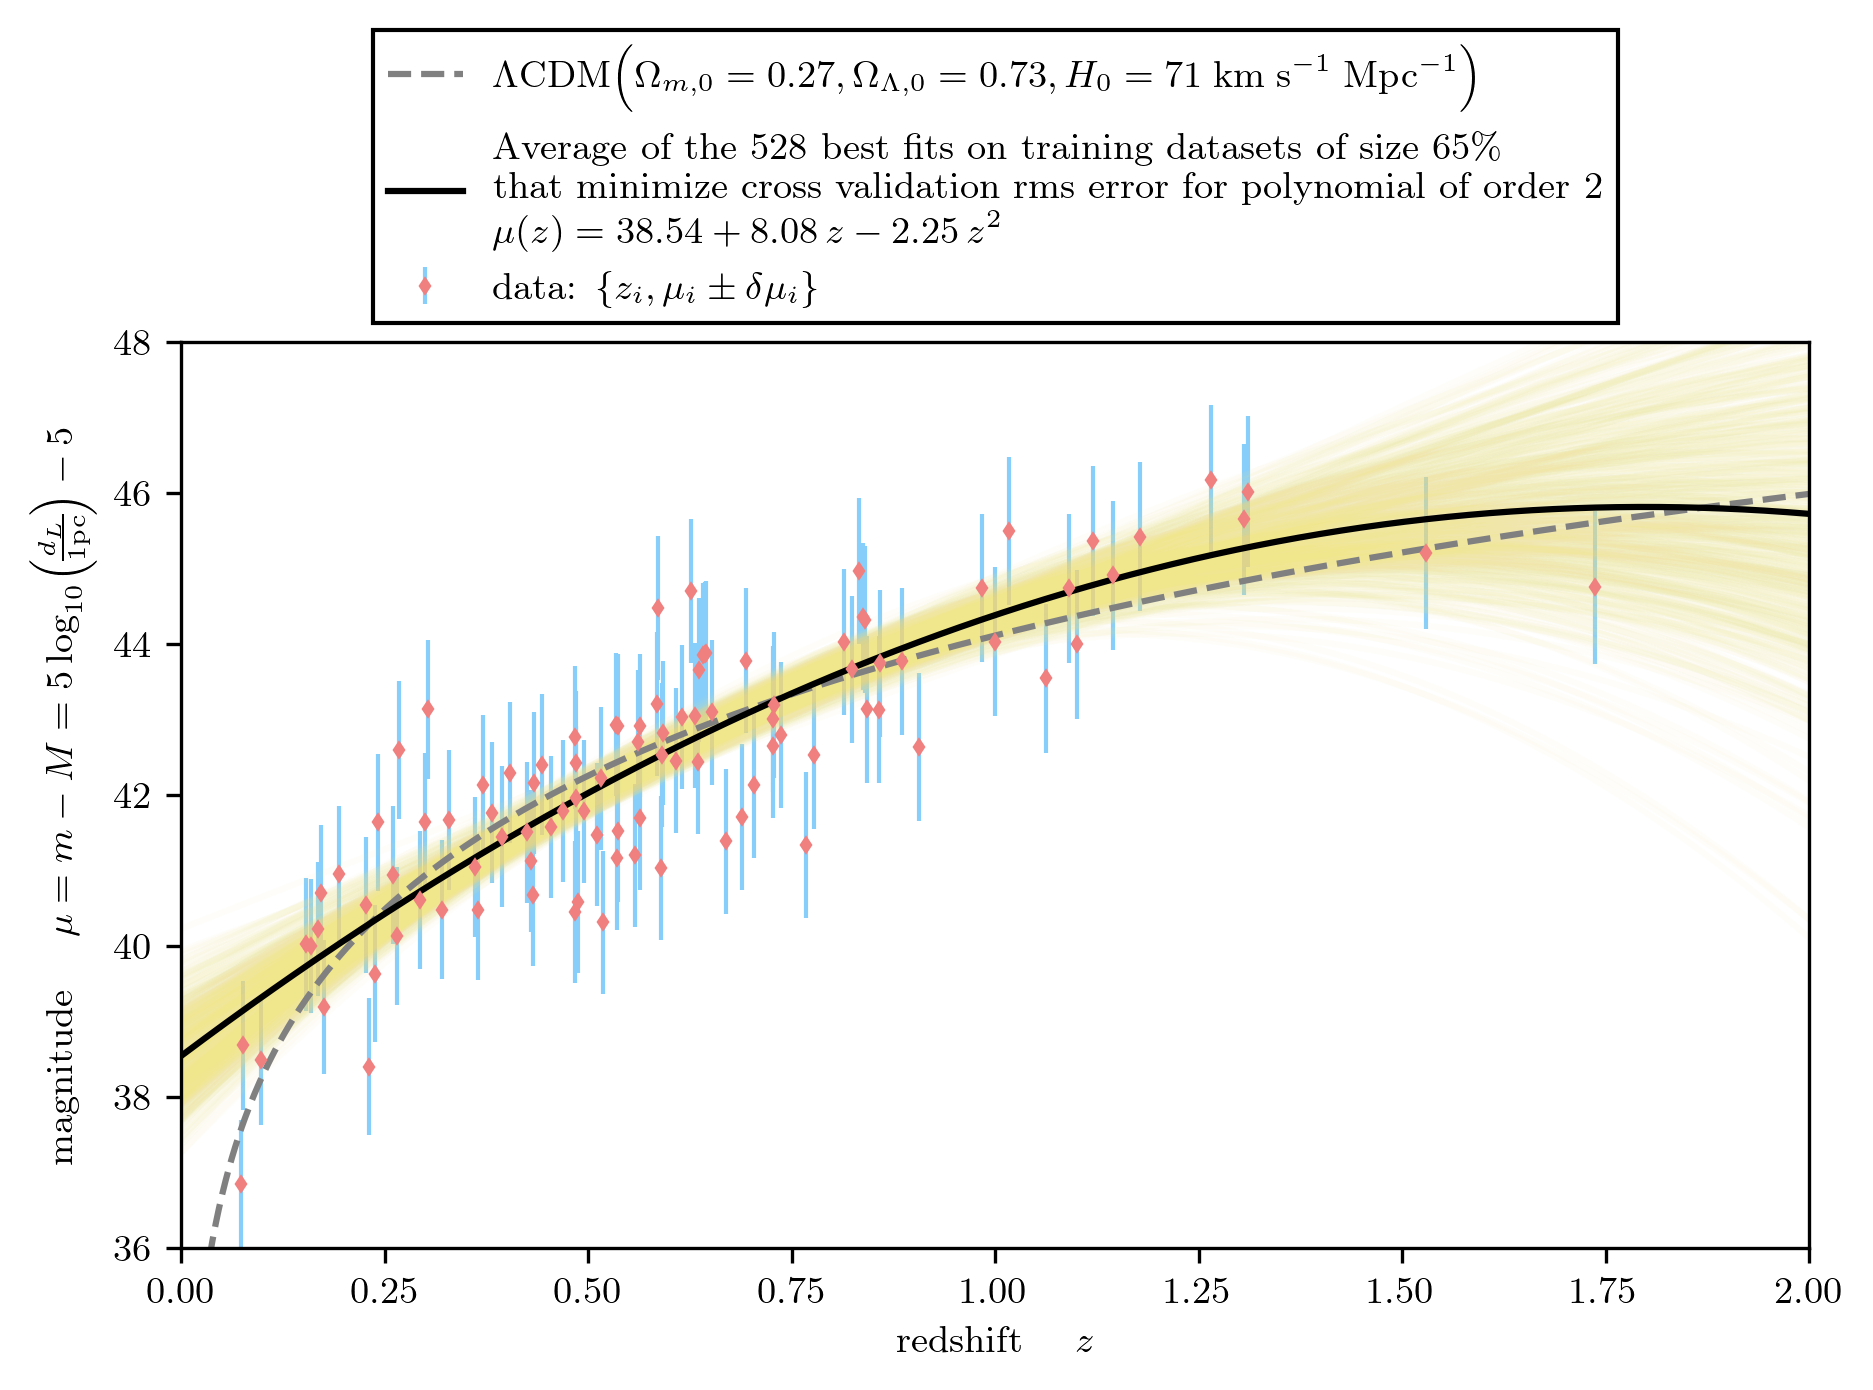

In [22]:
#-------------------------------------------------------------------------
# finally plot the best fit curve as average of the cross validated models
#-------------------------------------------------------------------------

fig , ax = plt.subplots(figsize=(7,4))


ax.errorbar(z_sample, mu_sample, dmu, color='lightcoral', marker='d', markersize=2, ecolor='lightskyblue', ls='', lw=1, label='data: $\{z_i, \mu_i \pm \delta\mu_i\}$')

ax.set_xlabel(r"redshift $\quad z$")
ax.set_ylabel(r"magnitude $\quad \mu = m - M = 5 \log_{10}\!\left(\!\frac{d_L}{\rm 1 pc}\!\right) - 5$")
ax.set_xlim(0,2)
ax.set_ylim(36,48)

# ax.plot(z_grid, mu_grid_CV, color=color1ist[best_deg_CV-1], label=best_label)  
for i in range(N_best_degs):
    ax.plot(z_grid, mu_grid_onlybest[i,:], color='khaki', alpha=0.05) 

labellina = 'Average of the {:d} best fits on training datasets of size 65\%\n'.format(N_best_degs)
labellina += 'that minimize cross validation rms error for polynomial of order {:d}\n'.format(best_deg_CV)
labellina += '$\mu(z) = {:.2f}'.format(best_theta_onlybest_avg[0])
if best_theta_onlybest_avg[1] >= 0:
    labellina += '+ {:.2f} \, z '.format(best_theta_onlybest_avg[1])
else:
    labellina += '{:.2f} \, z '.format(best_theta_onlybest_avg[1])
if best_theta_onlybest_avg[2] >= 0:
    labellina += '+ {:.2f} \, z^2 $'.format(best_theta_onlybest_avg[2])
else: 
    labellina += '{:.2f} \, z^2 $'.format(best_theta_onlybest_avg[2])

label_LCDM = r'$\Lambda$CDM$\big(\Omega_{m,0} =0.27 , \Omega_{\Lambda,0} = 0.73, H_0 = 71 \;\textup{km} \; \textup{s}^{-1} \; \textup{Mpc}^{-1}\big)$'
ax.plot(z_grid, mu_true, ls='--', color='gray', label=label_LCDM)

ax.plot(z_grid, mu_grid_onlybest_avg, color='black', label=labellina) 



_ = ax.legend(frameon=True, framealpha=1, fancybox=False, edgecolor='black', loc='lower center',bbox_to_anchor=(0.5,1.0)) #,bbox_to_anchor=(0.75,0))

#-------------------------------------------------------------------------

In [ ]:
_ = '''
#-------------------------------------------------------------------------
# just checking whether this mu(z) has reasonably manageable values

OmegaM0 = 0.27
OmegaL0 = 1 - OmegaM0
H0 = 71 # km s^-1 Mpc^-1
c  = 299792.458 # km s^-1
h0 = H0 / c * 3000 # Mpc
print(h0)
z_prova = 0.5
hyper_prova = (1+z_prova)*special.hyp2f1(1/3,1/2,4/3,-OmegaM0/OmegaL0*(1+z_prova)**3)
print(hyper_prova)
hyper_prova -= special.hyp2f1(1/3,1/2,4/3,-OmegaM0/OmegaL0)
print(hyper_prova)
hyper_prova = np.log10(hyper_prova)
print(hyper_prova)
hyper_prova += np.log10(1+z_prova)
print(hyper_prova)
hyper_prova -= np.log10(h0)
print(hyper_prova)
hyper_prova -= np.log10(OmegaL0) / 2
print(hyper_prova)
hyper_prova += const3e7
hyper_prova *= 5
print(hyper_prova)

hyper_prova_2 = mu_modellino(h0,OmegaL0,OmegaM0,z_prova)
print(hyper_prova_2)

# very manageable numbers indeed


print(z_sample.min(), z_sample.max())
print(mu_sample.min(), mu_sample.max())
print( mu_modellino([0.70,0.75,0.25], 0.75) )
print( mu_modellino([0.70,0.75,0.25], z_sample).min() , mu_modellino([0.70,0.75,0.25], z_sample).max() )

like_test  = log_likelihood([0.70,0.75,0.25],z_sample,mu_sample,dmu) 
prior_test = log_prior([0.70,0.75,0.25])
post_test  = log_posterior( [0.70,0.75,0.25], z_sample,mu_sample,dmu)
print(post_test)

aaa = np.array([0.70,0.75,0.25])
for i in range(10):
    post_test = log_posterior( aaa + aaa * 0.1 * np.random.random(),z_sample,mu_sample,dmu)
    print(post_test)



#-------------------------------------------------------------------------
# Monte Carlo Markov Chain - mu(z)
#-------------------------------------------------------------------------

# number of model parameters
n_dim     = 2    

# number of MCMC walkers
n_walkers = 10

# number of MCMC steps to take for each walker
n_steps   = 1000000

# initialize parameters x as: x0 + random(0,0.1) * x0
par0 = np.array([0.70,0.75])
starting_guesses = np.tile(par0,(n_walkers,1))
for i in range(n_walkers):
    for j in range(n_dim):
        starting_guesses[i][j] += par0[j] * 0.1 * np.random.random()

# just checking that starting guesses and posterior work as intended
for i in range(n_walkers):
    print(starting_guesses[i,:])
    print(log_posterior(starting_guesses[i,:],z_sample,mu_sample,dmu))
print() 

#-------------------------------------------------------------------------
# run the actual MCMC to sample the log posterior (not working)

sampler = emcee.EnsembleSampler(n_walkers, n_dim, log_posterior, args=(z_sample, mu_sample, dmu))
sampler.run_mcmc(starting_guesses, n_steps, progress=True)
'''

#-------------------------------------------------------------------------